# Results Report

This notebook is the narrative entry point for the paper's results. It ties
the headline numbers and figures to the evidence layers — claims **C1/C2/C3**,
criterion **D**, and method **M** — and states each conclusion precisely
(no overclaiming).

All numbers come from `results/paper/*.csv`; the paper figures (`e*`) are
embedded from `output/02_paper_figures/`; two explanatory figures (`x2`, `x3`)
are rendered inline from their CSVs and are **notebook-only — not paper
figures**. Markdown is English; chart labels are English.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

from ks_core.plotting import (
    METHOD_PALETTE,
    add_reference_line,
    make_figure,
    savefig_academic,
    setup_academic_style,
)

def _find_project_root() -> Path:
    """Locate the repo root from the current working directory.

    Works whether the notebook is launched from the repo root (Jupyter Lab)
    or from its own directory (headless ``nbconvert``/``jupyter execute``).
    """
    for base in (Path.cwd(), *Path.cwd().parents):
        if (base / "results" / "paper").is_dir():
            return base
    return Path.cwd()


PROJECT_ROOT = _find_project_root()
RESULTS = PROJECT_ROOT / "results" / "paper"
PAPER_FIGURES = PROJECT_ROOT / "output" / "02_paper_figures"
OUTPUT_DIR = PROJECT_ROOT / "output" / "03_results_report"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

setup_academic_style()
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

CASE_ORDER = [
    "Conv_Case0",
    "Conv_Case1",
    "FlashAttention_Case0",
    "FlashAttention_Case1",
    "Matmul_Case0",
    "Matmul_Case1",
]

# Result tables (paper SSOT).
headline = pd.read_csv(RESULTS / "e1_headline.csv")
e2_cv = pd.read_csv(RESULTS / "e2_victim_cv.csv")
e2_order = pd.read_csv(RESULTS / "e2_victim_order.csv")
e6_corr = pd.read_csv(RESULTS / "e6_corr.csv")
e7 = pd.read_csv(RESULTS / "e7_misalign.csv")
e8 = pd.read_csv(RESULTS / "e8_prefetch.csv")
e9 = pd.read_csv(RESULTS / "e9_working_set.csv")
e10 = pd.read_csv(RESULTS / "e10_portfolio.csv")
e11_ablation = pd.read_csv(RESULTS / "e11_synth_ablation.csv")
e11_orders = pd.read_csv(RESULTS / "e11_synth_orders.csv")

# Problem-framing tables (read, not recomputed).
case_summary = pd.read_csv(RESULTS / "inv_case_summary.csv")
problem_overview = pd.read_csv(RESULTS / "prob_overview.csv")
capacities = pd.read_csv(RESULTS / "prob_capacities.csv")

# Explanatory (notebook-only) figure data.
x2_timeline = pd.read_csv(RESULTS / "x2_clean_dirty_timeline.csv")
x2_split = pd.read_csv(RESULTS / "x2_cost_split.csv")
x3_traj = pd.read_csv(RESULTS / "x3_portfolio_traj.csv", dtype={"iter": str})


def note(text: str) -> None:
    """Render a one-line takeaway callout."""
    display(Markdown(f"> **Takeaway.** {text}"))


def show_png(name: str, width: int = 900) -> None:
    """Embed a paper figure from output/02_paper_figures/."""
    path = PAPER_FIGURES / name
    if path.exists():
        display(Image(filename=str(path), width=width))
    else:
        display(Markdown(f"`Missing figure: {path}` — build 02_paper_figures first."))


def save_fig(fig, name):
    """Save an inline explanatory figure to output/03_results_report/."""
    savefig_academic(fig, OUTPUT_DIR / name)
    print(f"Saved: output/03_results_report/{name}")
    return fig


def ordered_cases(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["case"] = pd.Categorical(out["case"], categories=CASE_ORDER, ordered=True)
    return out.sort_values(["case"])

## 1. Executive summary

The promoted solver is `iter038_id_raw_candidate`. All 18 case/problem rows
are valid; it wins 13 rows against the baseline and wins all six P1 rows.

In [2]:
best_iter_path = PROJECT_ROOT / "algorithms" / "autoresearch" / "best_iter.txt"
promoted = best_iter_path.read_text().strip() if best_iter_path.exists() else "iter038_id_raw_candidate"

summary = pd.DataFrame(
    [
        {"metric": "valid rows", "value": "18 / 18"},
        {"metric": "wins vs baseline", "value": f"{(headline.result == 'WIN').sum()} / {len(headline)}"},
        {"metric": "P1 wins", "value": f"{((headline.problem == 1) & (headline.result == 'WIN')).sum()} / 6"},
        {"metric": "promoted solver", "value": promoted},
    ]
)
display(summary)

win_loss = (
    headline.assign(case=pd.Categorical(headline["case"], categories=CASE_ORDER, ordered=True))
    .pivot(index="case", columns="problem", values="result")
    .sort_index()
    .rename(columns={1: "P1", 2: "P2", 3: "P3"})
)
display(win_loss)

note(
    "The claim is not universal dominance. The final solution is fully valid and "
    "reaches 13/18 wins by combining order shaping, spill selection, and reload "
    "placement — P1 is won outright, P2/P3 are won selectively."
)

,metric,value
0,valid rows,18 / 18
1,wins vs baseline,13 / 18
2,P1 wins,6 / 6
3,promoted solver,iter038_id_raw_candidate


problem,P1,P2,P3
case,,,
Conv_Case0,WIN,LOSS,LOSS
Conv_Case1,WIN,WIN,LOSS
FlashAttention_Case0,WIN,LOSS,WIN
FlashAttention_Case1,WIN,LOSS,WIN
Matmul_Case0,WIN,WIN,WIN
Matmul_Case1,WIN,WIN,WIN


> **Takeaway.** The claim is not universal dominance. The final solution is fully valid and reaches 13/18 wins by combining order shaping, spill selection, and reload placement — P1 is won outright, P2/P3 are won selectively.

## 2. Benchmark scope

Just enough scope to interpret the solver: the six instance scales, the three
problem objectives, and the cache capacities. (Full inventory and validation
live in `01_data_and_problem`.)

In [3]:
display(
    ordered_cases(case_summary)[
        ["case", "kernel", "scale", "total_nodes", "total_edges", "op_nodes", "unique_buffers", "total_buf_size"]
    ]
)

display(problem_overview.style.set_properties(**{"text-align": "left"}))
display(capacities)

note(
    "P1 only requires an original-node topological order; P2/P3 additionally "
    "require physical offsets and spill lists, so low P1 pressure does not "
    "automatically imply low P2/P3 cost."
)

,case,kernel,scale,total_nodes,total_edges,op_nodes,unique_buffers,total_buf_size
0,Conv_Case0,Conv,small,2580,3869,918,831,150807
1,Conv_Case1,Conv,large,36086,85653,12060,12013,570168
2,FlashAttention_Case0,FlashAttention,small,1716,2712,572,572,64264
3,FlashAttention_Case1,FlashAttention,large,6952,11184,2296,2328,248976
4,Matmul_Case0,Matmul,small,4160,7104,1728,1216,163840
5,Matmul_Case1,Matmul,large,30976,55040,13056,8960,1179648


,problem,optimization_target,output_files,metric_formula,direction
0,Problem 1,Minimize peak resident cache demand for a valid topological schedule,_schedule.txt,max prefix V_stay over ALLOC/FREE size deltas,minimize maxV_stay
1,Problem 2,Assign cache offsets and spills under capacity constraints,"_schedule.txt, _memory.txt, _spill.txt",sum spill cost: Size or 2*Size depending on COPY_IN usage,minimize extra DDR traffic
2,Problem 3,Reduce pipelined execution time with spill and reuse dependencies,"_schedule.txt, _memory.txt, _spill.txt","T = max E(v) under DAG, same-pipe, spill, and reuse constraints",minimize total time


,cache,capacity
0,L1,4096
1,UB,1024
2,L0A,256
3,L0B,256
4,L0C,512


> **Takeaway.** P1 only requires an original-node topological order; P2/P3 additionally require physical offsets and spill lists, so low P1 pressure does not automatically imply low P2/P3 cost.

## 3. Solver architecture

The method is not a single heuristic. It is a small portfolio of generic
candidate orders evaluated by the true official key, so adding a candidate can
only improve or tie the selected result.

In [4]:
architecture = pd.DataFrame(
    [
        {"component": "P1 order", "implementation": "memory-aware list scheduler", "purpose": "minimize the official P1 residency key"},
        {"component": "P2/P3 candidate orders", "implementation": "capfit_id, p1, id_raw", "purpose": "cover capacity-throttled, P1-optimized, and native-id residency patterns"},
        {"component": "physical placement", "implementation": "address-ordered first fit over free intervals", "purpose": "assign cache offsets and expose overflow events"},
        {"component": "spill victim", "implementation": "cost-aware Belady-style next-use score", "purpose": "prefer far-future and cheaper clean COPY_IN buffers"},
        {"component": "P2 selection key", "implementation": "(extra, spills, time)", "purpose": "match the traffic-first objective"},
        {"component": "P3 selection key", "implementation": "(time, extra, spills)", "purpose": "match the time-first objective"},
        {"component": "P3 prefetch grid", "implementation": "H in {0, 5, 40, 80, 120}", "purpose": "hide SPILL_IN latency without evicting other buffers during prefetch"},
    ]
)
display(architecture)

note(
    "The candidate orders do not depend on case names. The value of `id_raw` is "
    "that it preserves native block flow, making clean COPY_IN buffers more "
    "available at overflow windows."
)

,component,implementation,purpose
0,P1 order,memory-aware list scheduler,minimize the official P1 residency key
1,P2/P3 candidate orders,"capfit_id, p1, id_raw","cover capacity-throttled, P1-optimized, and na..."
2,physical placement,address-ordered first fit over free intervals,assign cache offsets and expose overflow events
3,spill victim,cost-aware Belady-style next-use score,prefer far-future and cheaper clean COPY_IN bu...
4,P2 selection key,"(extra, spills, time)",match the traffic-first objective
5,P3 selection key,"(time, extra, spills)",match the time-first objective
6,P3 prefetch grid,"H in {0, 5, 40, 80, 120}",hide SPILL_IN latency without evicting other b...


> **Takeaway.** The candidate orders do not depend on case names. The value of `id_raw` is that it preserves native block flow, making clean COPY_IN buffers more available at overflow windows.

## 4. Headline results

The core source for the paper's headline numbers, from
`results/paper/e1_headline.csv`.

In [5]:
headline_display = ordered_cases(headline)[
    [
        "case", "problem", "result",
        "ours_max_L1", "ours_spills", "ours_extra", "ours_time",
        "base_max_L1", "base_spills", "base_extra", "base_time",
    ]
]
display(headline_display)

problem_summary = (
    headline.groupby(["problem", "result"], as_index=False)
    .size()
    .pivot(index="problem", columns="result", values="size")
    .fillna(0)
    .astype(int)
    .rename(index={1: "P1", 2: "P2", 3: "P3"})
)
display(problem_summary)

losses = headline[headline["result"].eq("LOSS")][
    ["case", "problem", "ours_extra", "base_extra", "ours_time", "base_time"]
].reset_index(drop=True)
display(losses)

note(
    "The five remaining losses stay visible. They show the residual gap is "
    "order-level cheap-buffer residency, not an evaluator or artifact-validity "
    "problem."
)

,case,problem,result,ours_max_L1,ours_spills,ours_extra,ours_time,base_max_L1,base_spills,base_extra,base_time
0,Conv_Case0,1,WIN,6912,0,0,394430,7488,0,0,359570
1,Conv_Case0,2,LOSS,6912,339,88044,615694,7488,141,73500,535312
2,Conv_Case0,3,LOSS,6912,342,92652,553280,7488,141,73500,535312
3,Conv_Case1,1,WIN,13786,0,0,650044,14040,0,0,573395
4,Conv_Case1,2,WIN,14040,1963,72520,1159169,14040,1828,73240,1150333
5,Conv_Case1,3,LOSS,14040,1951,73578,1111778,14040,1290,86690,1073322
7,FlashAttention_Case0,2,LOSS,3328,31,3904,51700,3328,41,3692,53374
8,FlashAttention_Case0,3,WIN,4096,58,5832,46167,3328,24,4128,46761
6,FlashAttention_Case0,1,WIN,256,0,0,31063,3328,0,0,31429
9,FlashAttention_Case1,1,WIN,256,0,0,112458,5376,0,0,113445


result,LOSS,WIN
problem,,
P1,0,6
P2,3,3
P3,2,4


,case,problem,ours_extra,base_extra,ours_time,base_time
0,Conv_Case0,2,88044,73500,615694,535312
1,Conv_Case0,3,92652,73500,553280,535312
2,Conv_Case1,3,73578,86690,1111778,1073322
3,FlashAttention_Case0,2,3904,3692,51700,53374
4,FlashAttention_Case1,2,32920,32840,214361,193059


> **Takeaway.** The five remaining losses stay visible. They show the residual gap is order-level cheap-buffer residency, not an evaluator or artifact-validity problem.

## 5. Result interpretation

Translating the win/loss matrix into the paper narrative — without overstating
13/18 as universal dominance.

In [6]:
interpretation = pd.DataFrame(
    [
        {"observation": "P1 wins all cases", "evidence": "6 / 6 P1 rows are WIN", "interpretation": "the memory-aware order is strong for the official P1 key"},
        {"observation": "P2/P3 wins are mixed", "evidence": "P2 has 3 wins; P3 has 4 wins", "interpretation": "physical placement, spill cost, and time placement add separate constraints"},
        {"observation": "Conv0 remains hard", "evidence": "Conv_Case0 loses P2 and P3", "interpretation": "the schedule still lacks enough cheap clean buffers at the right overflow window"},
        {"observation": "Matmul is stable", "evidence": "Matmul_Case0 and Matmul_Case1 win P1/P2/P3", "interpretation": "the candidate-order portfolio plus prefetch is sufficient for these cases"},
        {"observation": "FA has split behavior", "evidence": "FA P2 rows lose narrowly; FA P3 rows win", "interpretation": "prefetch placement improves time even when traffic is not always lower"},
    ]
)
display(interpretation)

note(
    "The losses are boundaries and next-step evidence, not something to hide. "
    "They support the thesis that schedule order is the main lever."
)

,observation,evidence,interpretation
0,P1 wins all cases,6 / 6 P1 rows are WIN,the memory-aware order is strong for the offic...
1,P2/P3 wins are mixed,P2 has 3 wins; P3 has 4 wins,"physical placement, spill cost, and time place..."
2,Conv0 remains hard,Conv_Case0 loses P2 and P3,the schedule still lacks enough cheap clean bu...
3,Matmul is stable,Matmul_Case0 and Matmul_Case1 win P1/P2/P3,the candidate-order portfolio plus prefetch is...
4,FA has split behavior,FA P2 rows lose narrowly; FA P3 rows win,prefetch placement improves time even when tra...


> **Takeaway.** The losses are boundaries and next-step evidence, not something to hide. They support the thesis that schedule order is the main lever.

## 6. C1 — order dominates victim policy

Precise claim: we do **not** say victim policy is always below 1%. The safer,
supported statement is that order-induced traffic ranges dominate
victim-policy ranges.

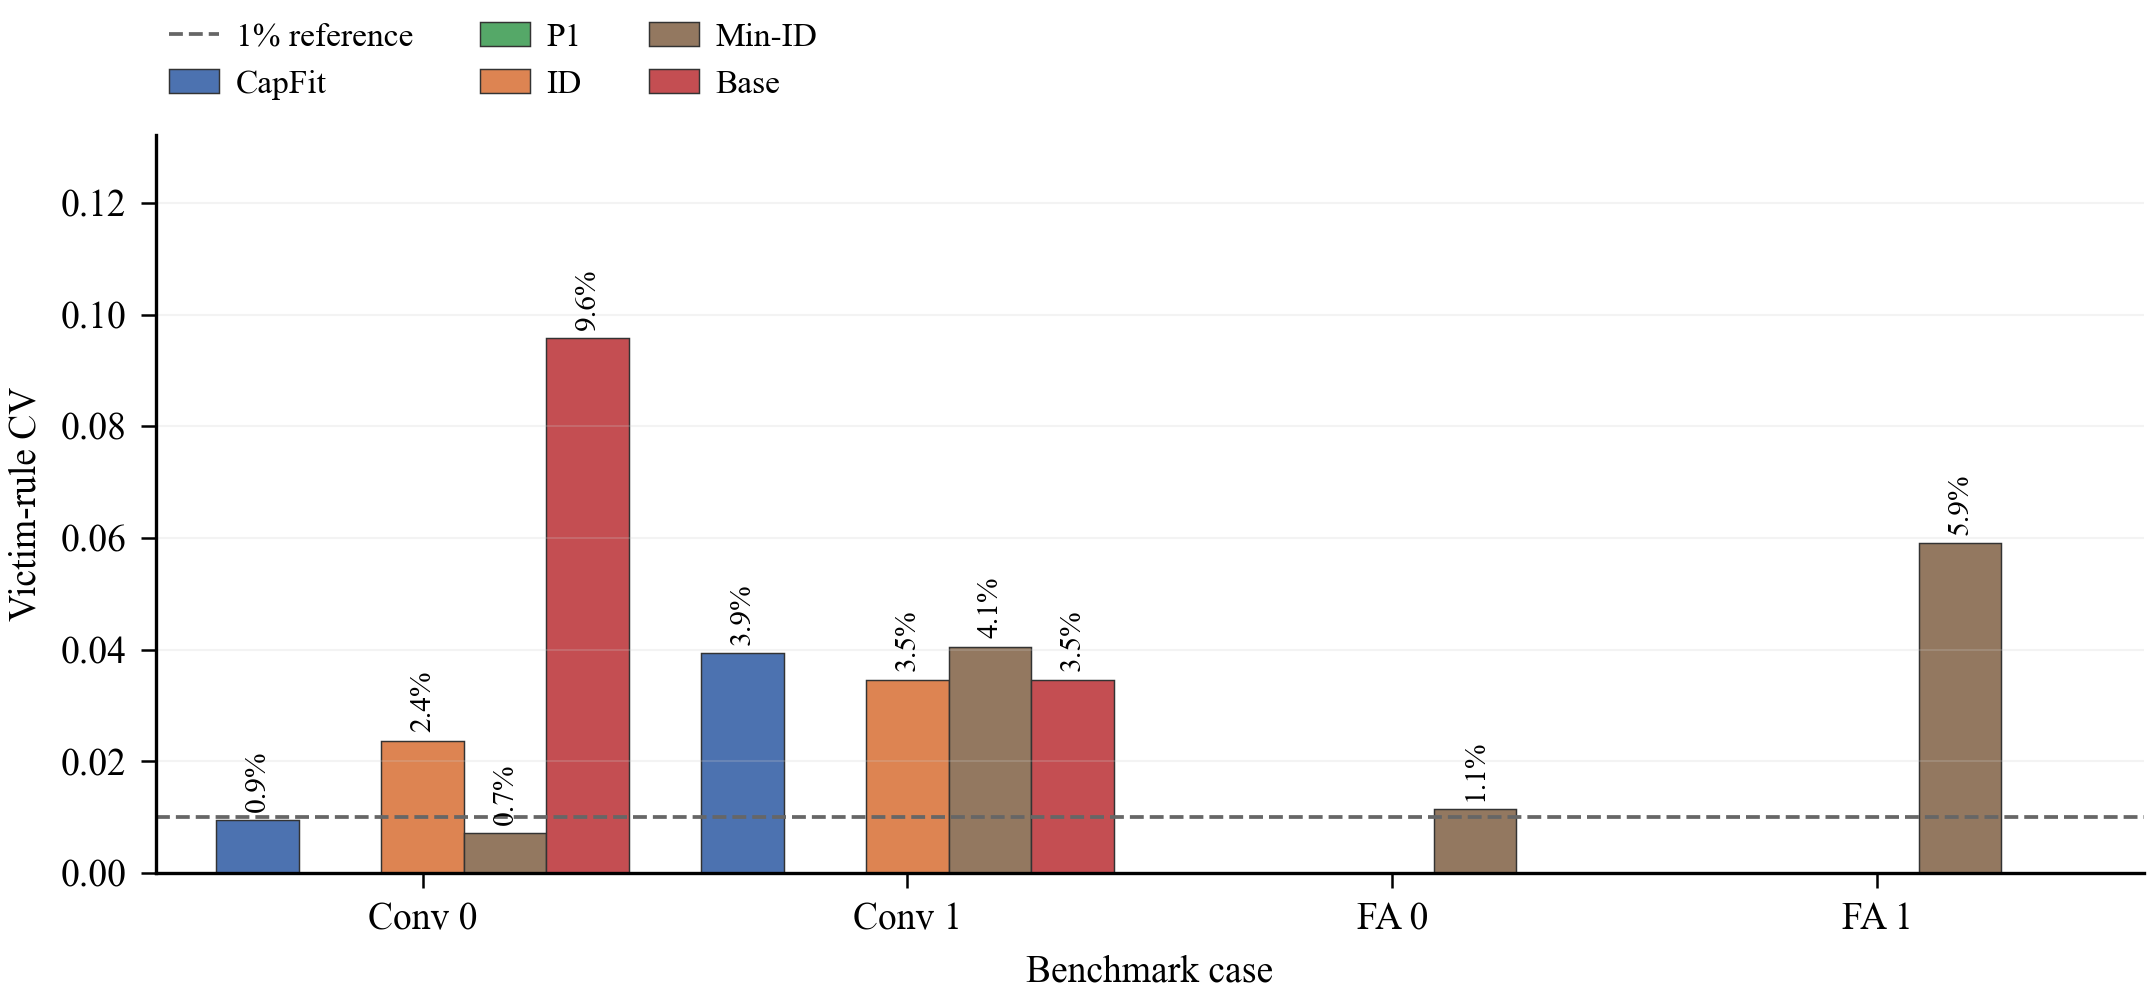

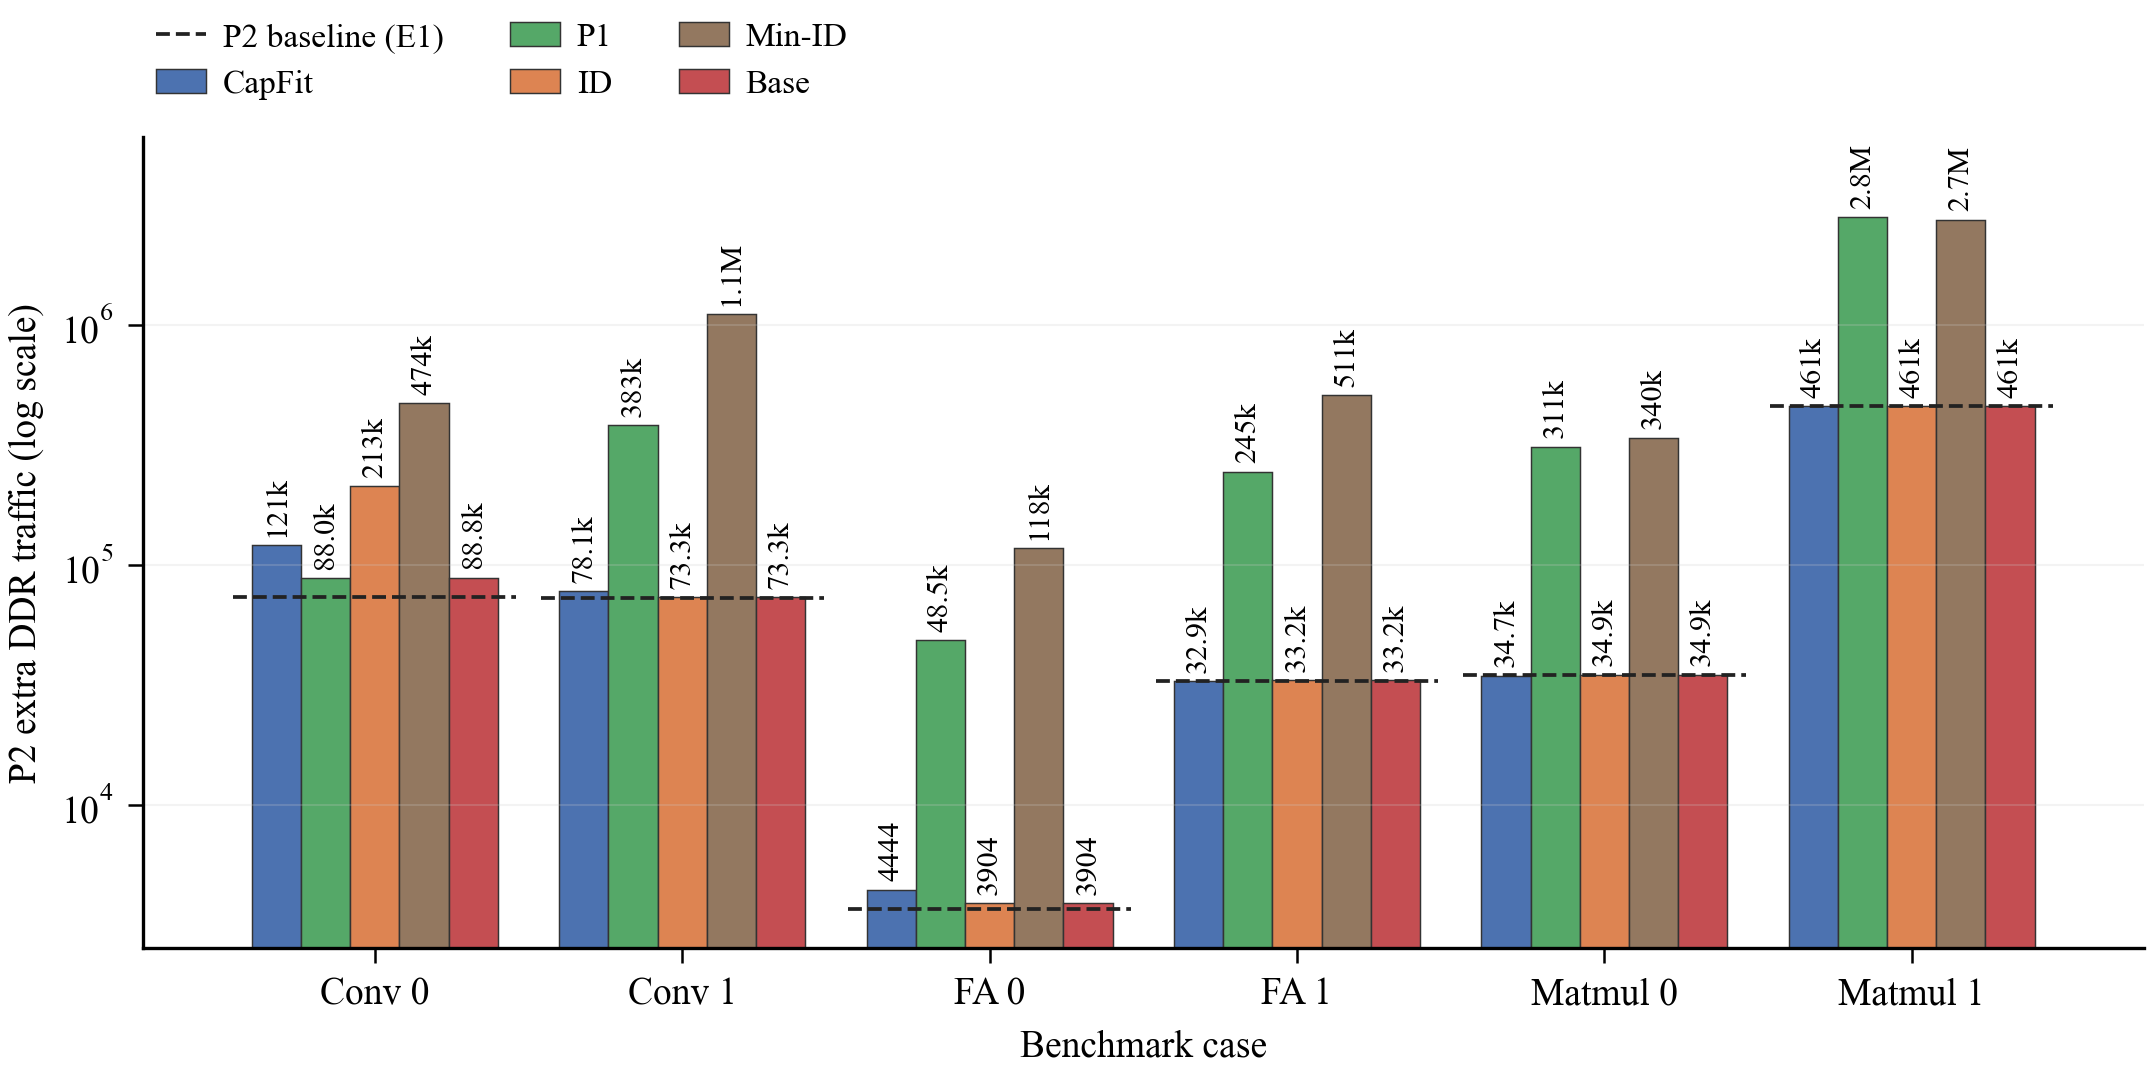

,case,order_min,order_max,order_range,victim_range,order_vs_victim_range
0,Conv_Case0,74076,483257,409181,16568,24.697067
1,Conv_Case1,73348,1204274,1130926,96798,11.683361
2,FlashAttention_Case0,3904,120592,116688,3072,37.984375
3,FlashAttention_Case1,32920,575536,542616,64512,8.411086
4,Matmul_Case0,34688,340224,305536,0,<NA>
5,Matmul_Case1,460800,2818048,2357248,0,<NA>


,metric,value
0,rows with CV < 1%,22
1,total rows,30
2,max CV,9.58%


> **Takeaway.** Victim scoring is not irrelevant, but it is not the main bottleneck. The schedule decides whether cheap clean buffers exist at overflow windows.

In [7]:
show_png("e2_victim_sensitivity.png")
show_png("e3_order_sensitivity.png")

order_range = e2_order.groupby("case")["extra"].agg(order_min="min", order_max="max")
order_range["order_range"] = order_range["order_max"] - order_range["order_min"]
victim_range = (
    e2_order.groupby(["case", "order"])["extra"]
    .agg(victim_min="min", victim_max="max")
    .assign(victim_range=lambda df: df["victim_max"] - df["victim_min"])
    .groupby("case")["victim_range"]
    .max()
)
range_table = order_range.join(victim_range).reset_index()
range_table["order_vs_victim_range"] = range_table["order_range"] / range_table["victim_range"].replace(0, pd.NA)
display(range_table)

cv_summary = pd.DataFrame(
    [
        {"metric": "rows with CV < 1%", "value": int((e2_cv["cv"] < 0.01).sum())},
        {"metric": "total rows", "value": len(e2_cv)},
        {"metric": "max CV", "value": f"{e2_cv['cv'].max() * 100:.2f}%"},
    ]
)
display(cv_summary)

note(
    "Victim scoring is not irrelevant, but it is not the main bottleneck. The "
    "schedule decides whether cheap clean buffers exist at overflow windows."
)

## 7. C1 mechanism — clean vs dirty residency

COPY_IN buffers behave like clean pages whose spill-out needs no write-back;
computed buffers behave like dirty pages whose spill costs 2× (write-back then
read-back).

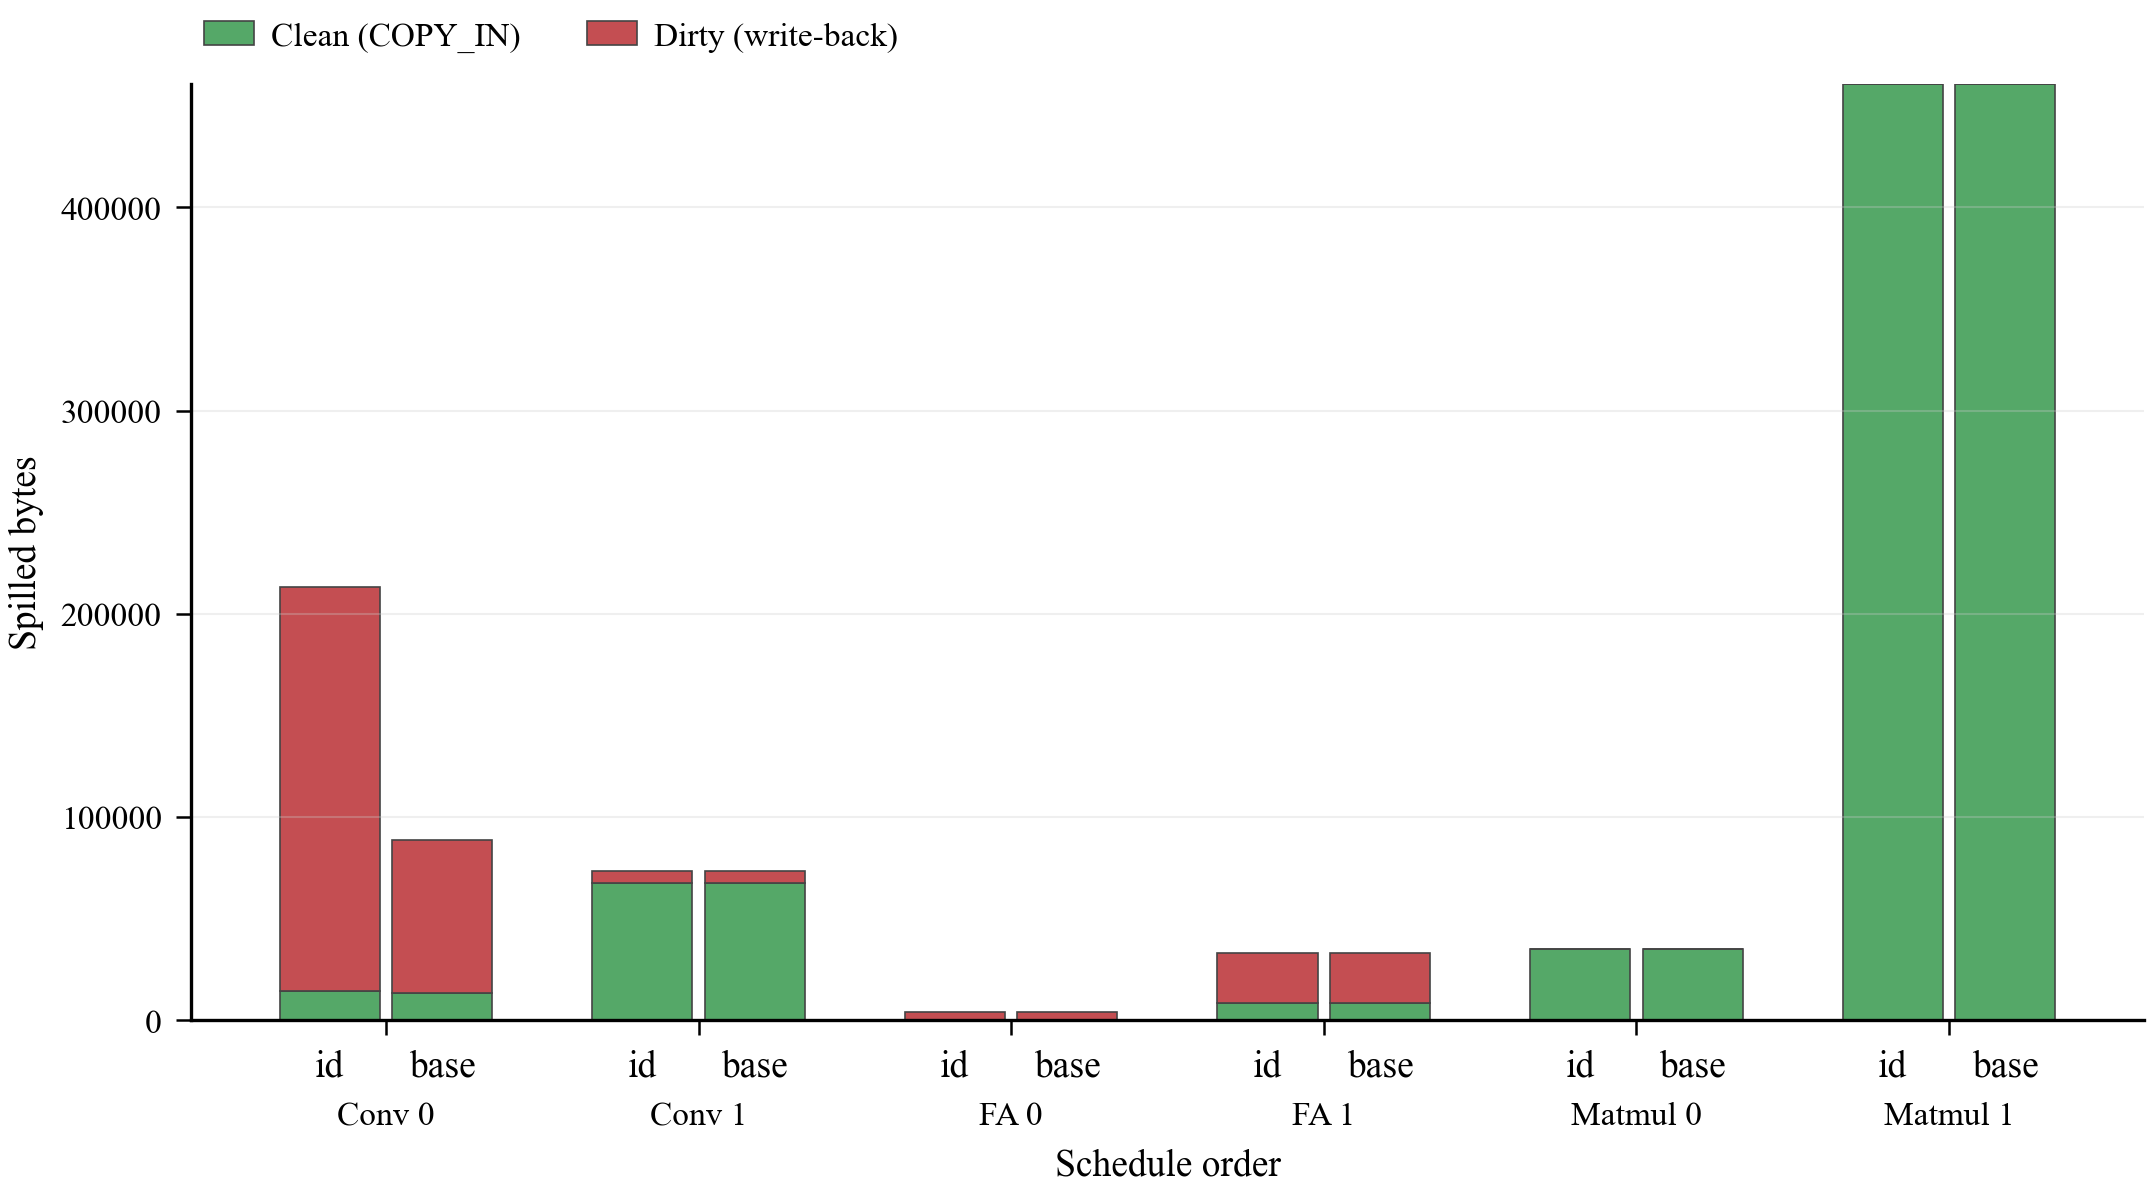

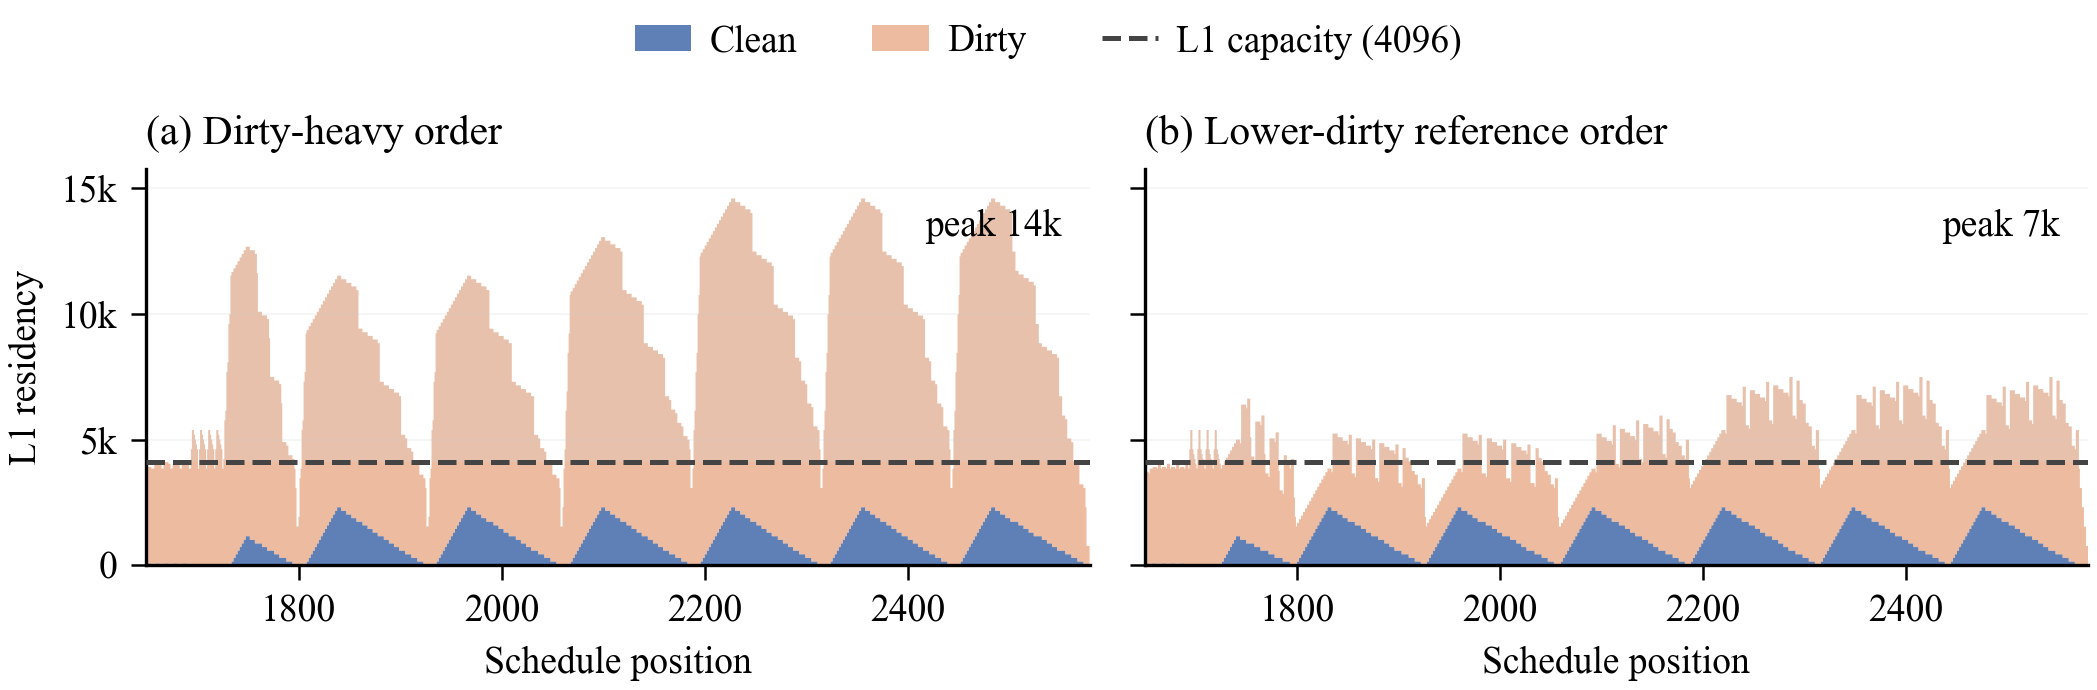

,case,order,extra,clean_bytes,dirty_bytes,clean_share
16,Conv_Case0,baseline,88768,13104,75664,0.147621
8,Conv_Case0,id_raw,212956,14400,198556,0.067620
36,Conv_Case1,baseline,73348,67520,5828,0.920543
28,Conv_Case1,id_raw,73348,67520,5828,0.920543
56,FlashAttention_Case0,baseline,3904,0,3904,0.000000
48,FlashAttention_Case0,id_raw,3904,0,3904,0.000000
76,FlashAttention_Case1,baseline,33152,8448,24704,0.254826
68,FlashAttention_Case1,id_raw,33152,8448,24704,0.254826
96,Matmul_Case0,baseline,34944,34944,0,1.000000
88,Matmul_Case0,id_raw,34944,34944,0,1.000000


> **Takeaway.** Do not conflate E4 and E5: E4 is about spill-byte composition; E5 is about clean/dirty residency along the schedule timeline.

In [8]:
show_png("e4_clean_dirty_composition.png")
show_png("e5_peak_residency.png")

composition = e2_order[
    e2_order["order"].isin(["id_raw", "baseline"]) & e2_order["victim"].eq("dist_size_cost")
].copy()
composition["spilled_bytes"] = composition["clean_bytes"] + composition["dirty_bytes"]
composition["clean_share"] = composition["clean_bytes"] / composition["spilled_bytes"]
display(
    composition[["case", "order", "extra", "clean_bytes", "dirty_bytes", "clean_share"]].sort_values(["case", "order"])
)

note(
    "Do not conflate E4 and E5: E4 is about spill-byte composition; E5 is about "
    "clean/dirty residency along the schedule timeline."
)

### Explanatory: anatomy of spill cost (Conv_Case0)

> **Explanatory figure (notebook-only) — not a paper figure.**

Why dirty residency is expensive, worked on a real instance: (a) the L1
clean/dirty residency timeline at the high-pressure window; (b) the
decomposition of P2 extra traffic into clean (×1) and dirty (×2) bytes. This
shows the *mechanism*, not a baseline comparison — on Conv_Case0 the promoted
order does not even win P2, yet the cost is still dominated by dirty write-backs.

Saved: output/03_results_report/x2_clean_dirty_steps.png


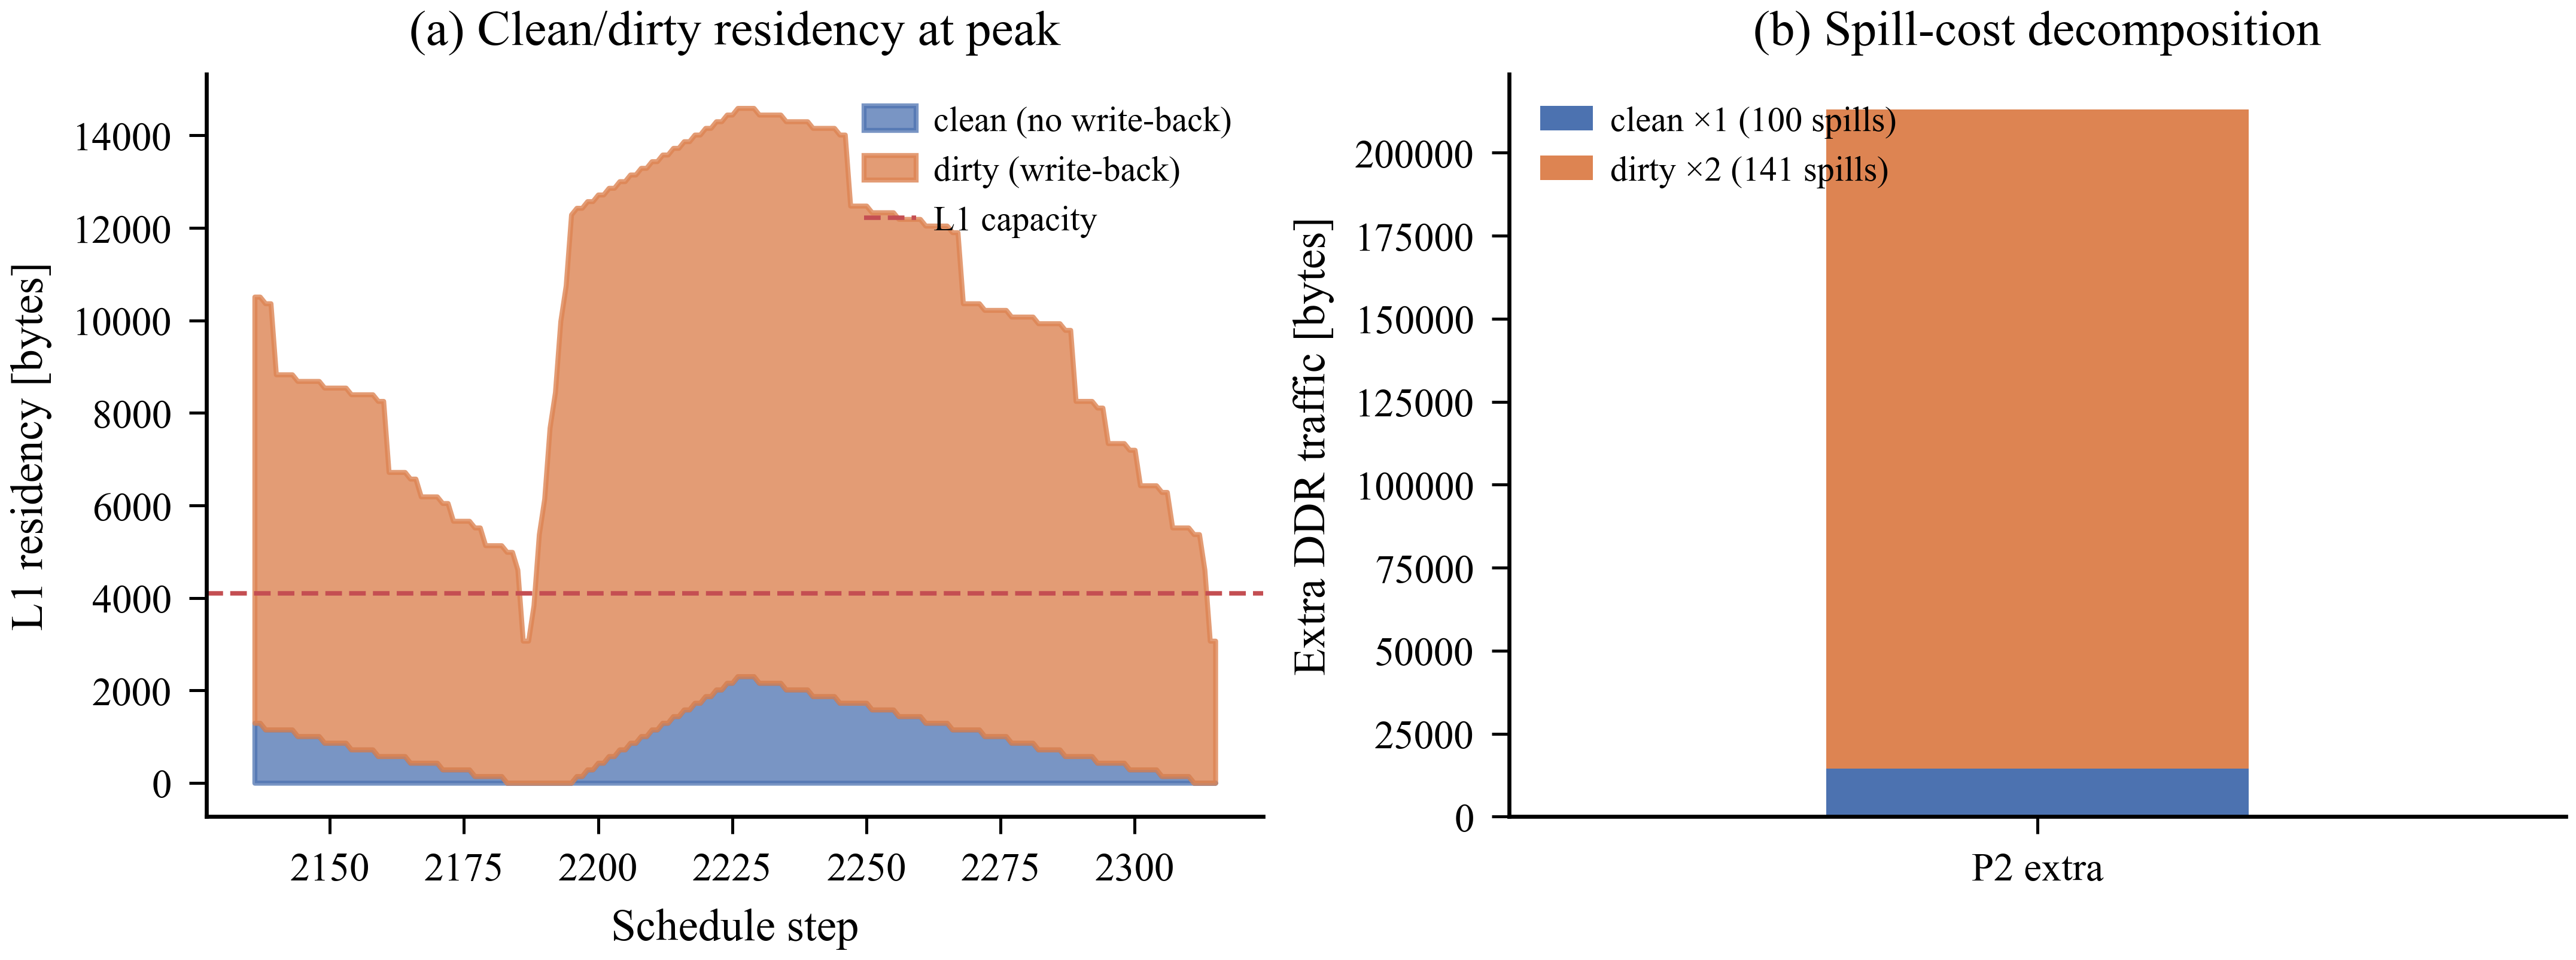

In [9]:
tl = x2_timeline.copy()
tl["total"] = tl["live_clean"] + tl["live_dirty"]
peak = int(tl["total"].idxmax())
lo, hi = max(0, peak - 90), min(len(tl) - 1, peak + 90)
seg = tl.iloc[lo:hi]
L1cap = int(capacities.set_index("cache").loc["L1", "capacity"])

fig, (axA, axB) = make_figure("double_col", ncols=2, height=2.7)
axA.fill_between(seg["pos"], 0, seg["live_clean"], color=METHOD_PALETTE["primary"], alpha=0.75, label="clean (no write-back)")
axA.fill_between(seg["pos"], seg["live_clean"], seg["total"], color=METHOD_PALETTE["accent_3"], alpha=0.8, label="dirty (write-back)")
add_reference_line(axA, L1cap, "L1 capacity", color=METHOD_PALETTE["accent_1"])
axA.set_xlabel("Schedule step")
axA.set_ylabel("L1 residency [bytes]")
axA.set_title("(a) Clean/dirty residency at peak")
axA.legend(fontsize=7, loc="upper right")

row = x2_split[x2_split["order"] == "id_raw"].iloc[0]
axB.bar(0, row["clean_bytes"], color=METHOD_PALETTE["primary"], label=f"clean ×1 ({int(row['clean_count'])} spills)")
axB.bar(0, row["dirty_bytes"], bottom=row["clean_bytes"], color=METHOD_PALETTE["accent_3"], label=f"dirty ×2 ({int(row['dirty_count'])} spills)")
axB.set_xlim(-1, 1)
axB.set_xticks([0])
axB.set_xticklabels(["P2 extra"])
axB.set_ylabel("Extra DDR traffic [bytes]")
axB.set_title("(b) Spill-cost decomposition")
axB.legend(fontsize=7, loc="upper left")
save_fig(fig, "x2_clean_dirty_steps.png")
fig

**Read.** At the L1 high-pressure window, dirty residency (orange) dwarfs
clean residency (blue), and the spill bill follows: the large majority of the
P2 extra traffic is dirty write-back+read-back bytes. This is exactly why the
method shapes liveness so that more of what stays resident — and what must be
evicted — is clean, halving its spill cost.

## 8. C1 generality check

A synthetic instance controls the clean/dirty reserve under the same
structure, checking that the 2× spill-cost asymmetry is not a Conv artifact.

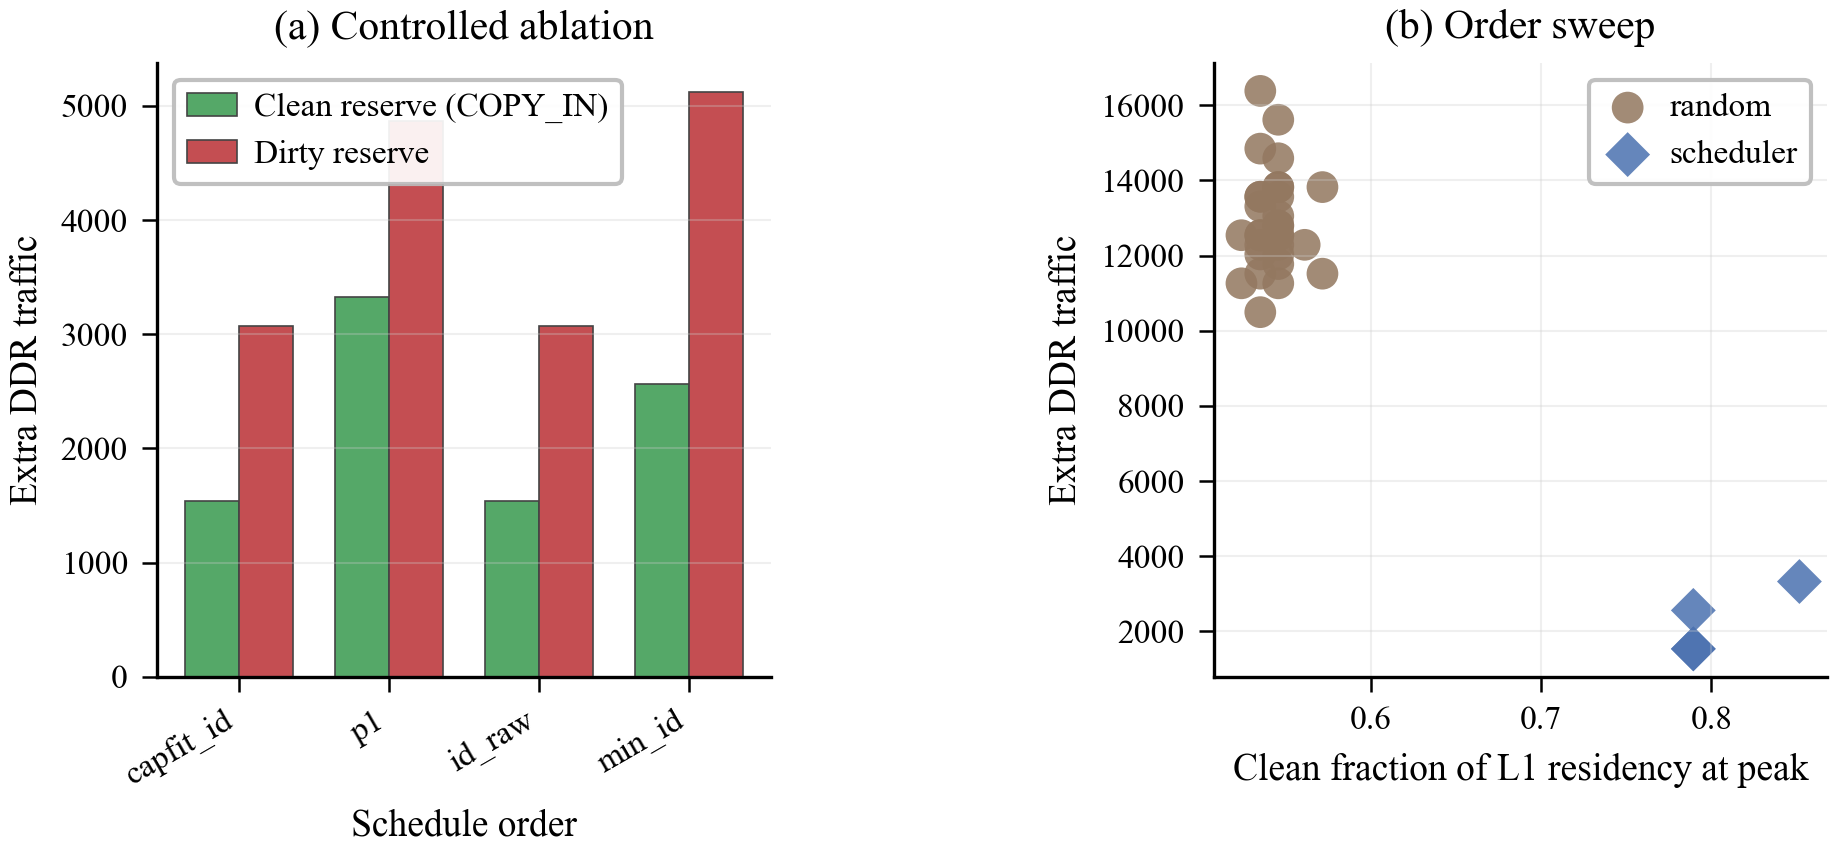

,reserve,order,extra,clean_bytes,dirty_bytes,spills,peak_total,peak_clean,peak_dirty
0,clean,capfit_id,1536,1536,0,3,4864,3840,1024
1,clean,p1,3328,3328,0,9,6912,5888,1024
2,clean,id_raw,1536,1536,0,3,4864,3840,1024
3,clean,min_id,2560,2560,0,5,4864,3840,1024
4,dirty,capfit_id,3072,0,3072,3,4864,256,4608
5,dirty,p1,4864,1792,3072,10,6912,2304,4608
6,dirty,id_raw,3072,0,3072,3,4864,256,4608
7,dirty,min_id,5120,0,5120,5,4864,256,4608


,metric,value
0,clean reserve extra,1536
1,dirty reserve extra,3072
2,spill count clean/dirty,3 / 3
3,peak total clean/dirty,4864 / 4864


> **Takeaway.** The robust statement is clean=1536, dirty=3072 with the same spill count, so dirty extra is exactly 2× — the asymmetry generalizes beyond Conv.

In [10]:
show_png("e11_synth_generality.png")
display(e11_ablation)

best_clean = e11_ablation[(e11_ablation["reserve"] == "clean") & (e11_ablation["order"] == "capfit_id")].iloc[0]
best_dirty = e11_ablation[(e11_ablation["reserve"] == "dirty") & (e11_ablation["order"] == "capfit_id")].iloc[0]
synthetic_check = pd.DataFrame(
    [
        {"metric": "clean reserve extra", "value": int(best_clean["extra"])},
        {"metric": "dirty reserve extra", "value": int(best_dirty["extra"])},
        {"metric": "spill count clean/dirty", "value": f"{int(best_clean['spills'])} / {int(best_dirty['spills'])}"},
        {"metric": "peak total clean/dirty", "value": f"{int(best_clean['peak_total'])} / {int(best_dirty['peak_total'])}"},
    ]
)
display(synthetic_check)

note(
    "The robust statement is clean=1536, dirty=3072 with the same spill count, so "
    "dirty extra is exactly 2× — the asymmetry generalizes beyond Conv."
)

## 9. C2 — overflow surrogate and objective mismatch

The value of the overflow surrogate Φ is not that it dramatically beats peak
pressure. It is lifetime-aware, cheap, and useful for portfolio selection.
Separately, the P1 lexicographic key and the P2/P3 objectives can be
misaligned.

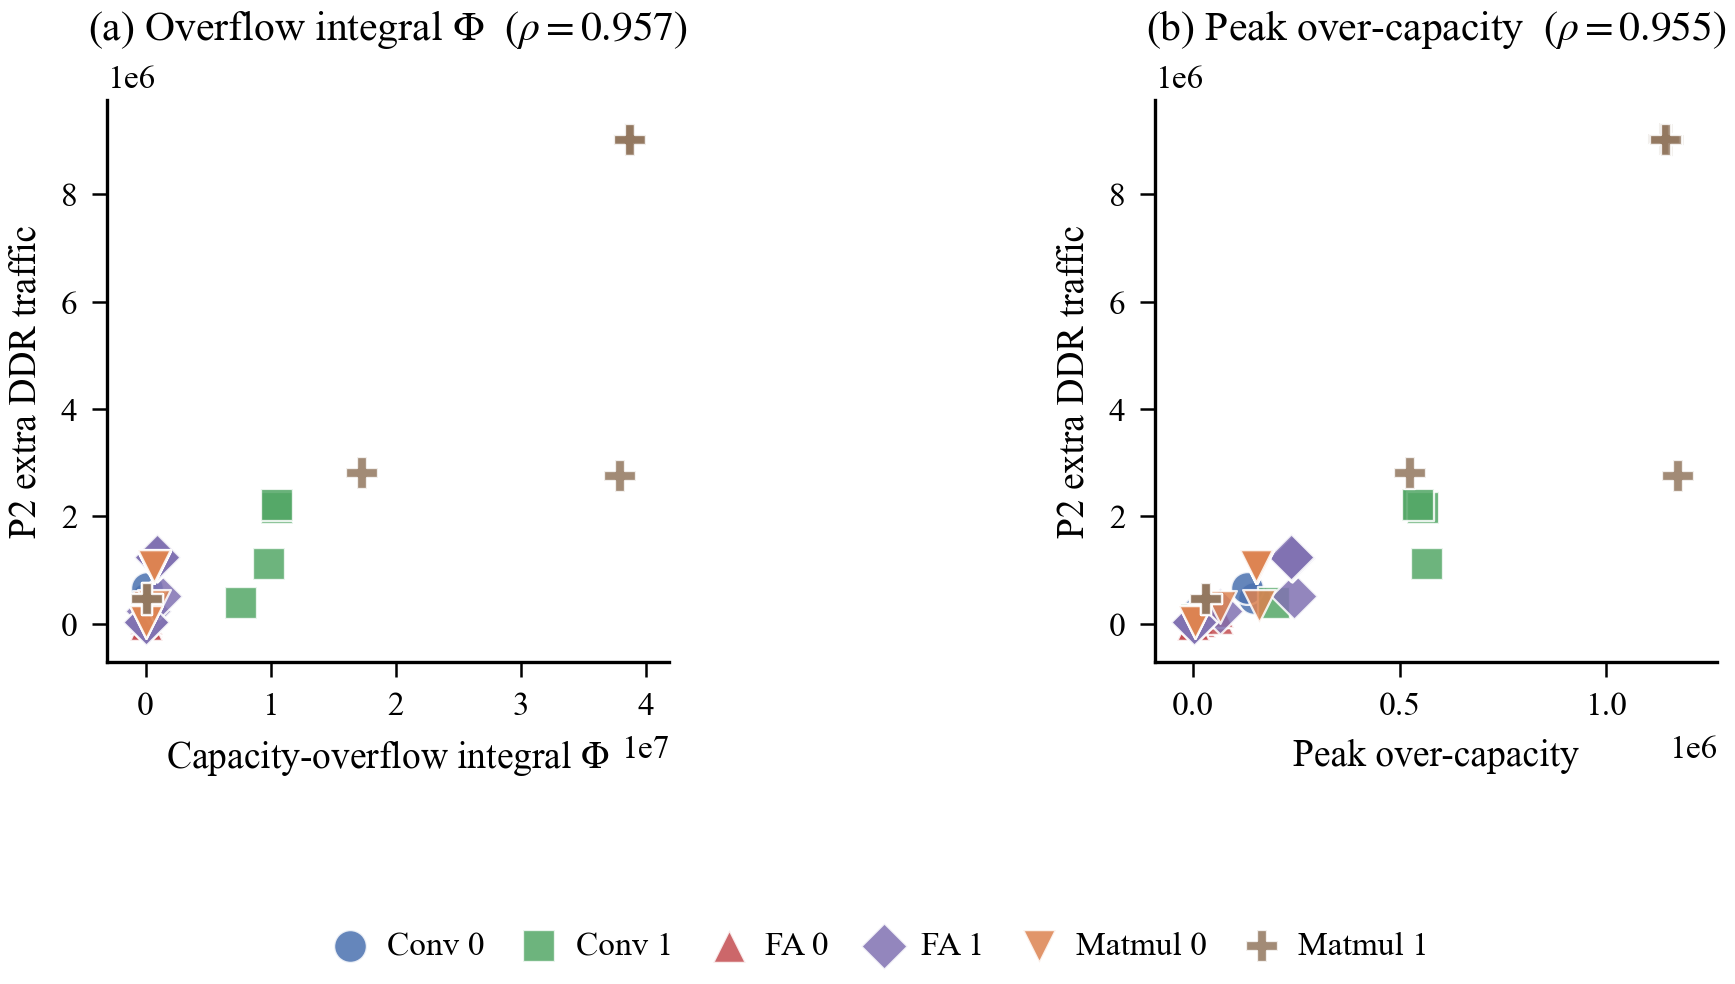

,case,spearman_phi_extra,spearman_peak_extra,spearman_phi_time,n
0,Conv_Case0,0.600000,0.600000,0.600000,6
1,Conv_Case1,0.540773,0.293252,0.685469,17
2,FlashAttention_Case0,0.207235,0.431204,0.247549,17
3,FlashAttention_Case1,0.469651,0.498156,0.519608,17
4,Matmul_Case0,0.426028,0.391253,0.570202,17
5,Matmul_Case1,0.408114,0.197044,0.604537,17
6,ALL,0.957471,0.954852,0.954726,91


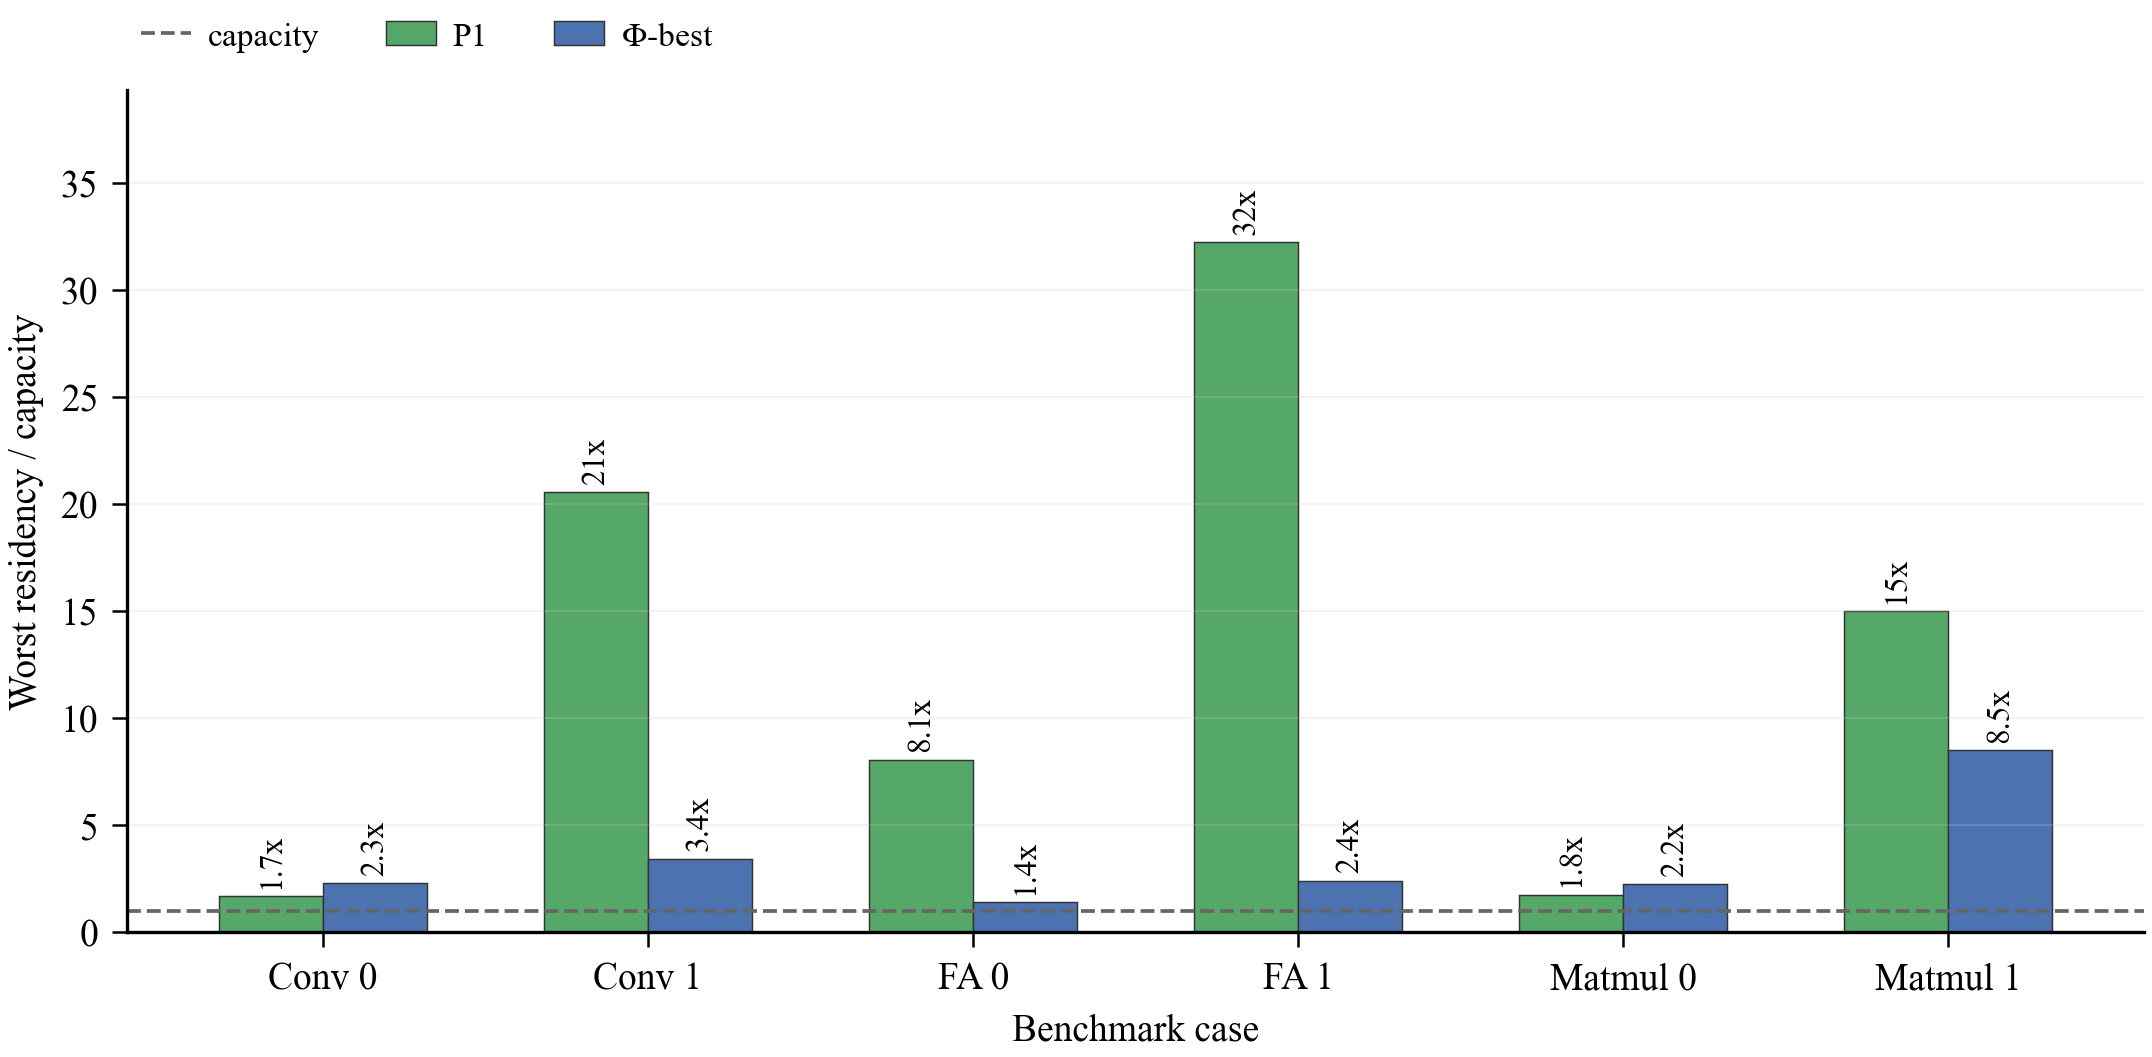

,case,order_kind,max_L1,max_UB,max_L0A_count,max_L0B_count,max_L0C_count,worst_over_ratio
0,Conv_Case0,p1,6912,0,0,300,0,1.687500
1,Conv_Case0,phi_best,9360,0,0,6,0,2.285156
2,Conv_Case1,p1,13786,0,0,5264,0,20.562500
3,Conv_Case1,phi_best,14040,0,0,1,0,3.427734
4,FlashAttention_Case0,p1,256,8258,24,32,4,8.064453
5,FlashAttention_Case0,phi_best,3328,1428,1,1,2,1.394531
6,FlashAttention_Case1,p1,256,33010,112,128,8,32.236328
7,FlashAttention_Case1,phi_best,5376,2468,2,2,2,2.410156
8,Matmul_Case0,p1,128,0,57,448,8,1.750000
9,Matmul_Case0,phi_best,9216,0,2,2,2,2.250000


> **Takeaway.** Global Spearman: Φ–extra = 0.9575, peak–extra = 0.9549. Both are strong, so Φ's advantage should not be overstated; its real benefit is being a cheap, lifetime-aware selection signal.

In [11]:
show_png("e6_surrogate.png")
display(e6_corr)

show_png("e7_misalignment_worst_ratio.png")
display(e7)

global_corr = e6_corr[e6_corr["case"].eq("ALL")].iloc[0]
note(
    f"Global Spearman: Φ–extra = {global_corr['spearman_phi_extra']:.4f}, "
    f"peak–extra = {global_corr['spearman_peak_extra']:.4f}. Both are strong, so "
    "Φ's advantage should not be overstated; its real benefit is being a cheap, "
    "lifetime-aware selection signal."
)

## 10. C3 — spill selection and reload placement decouple

P2 prioritizes extra traffic; P3 prioritizes time. Early SPILL_IN placement
can hide reload stalls but may increase extra traffic, so selection must
follow the official key.

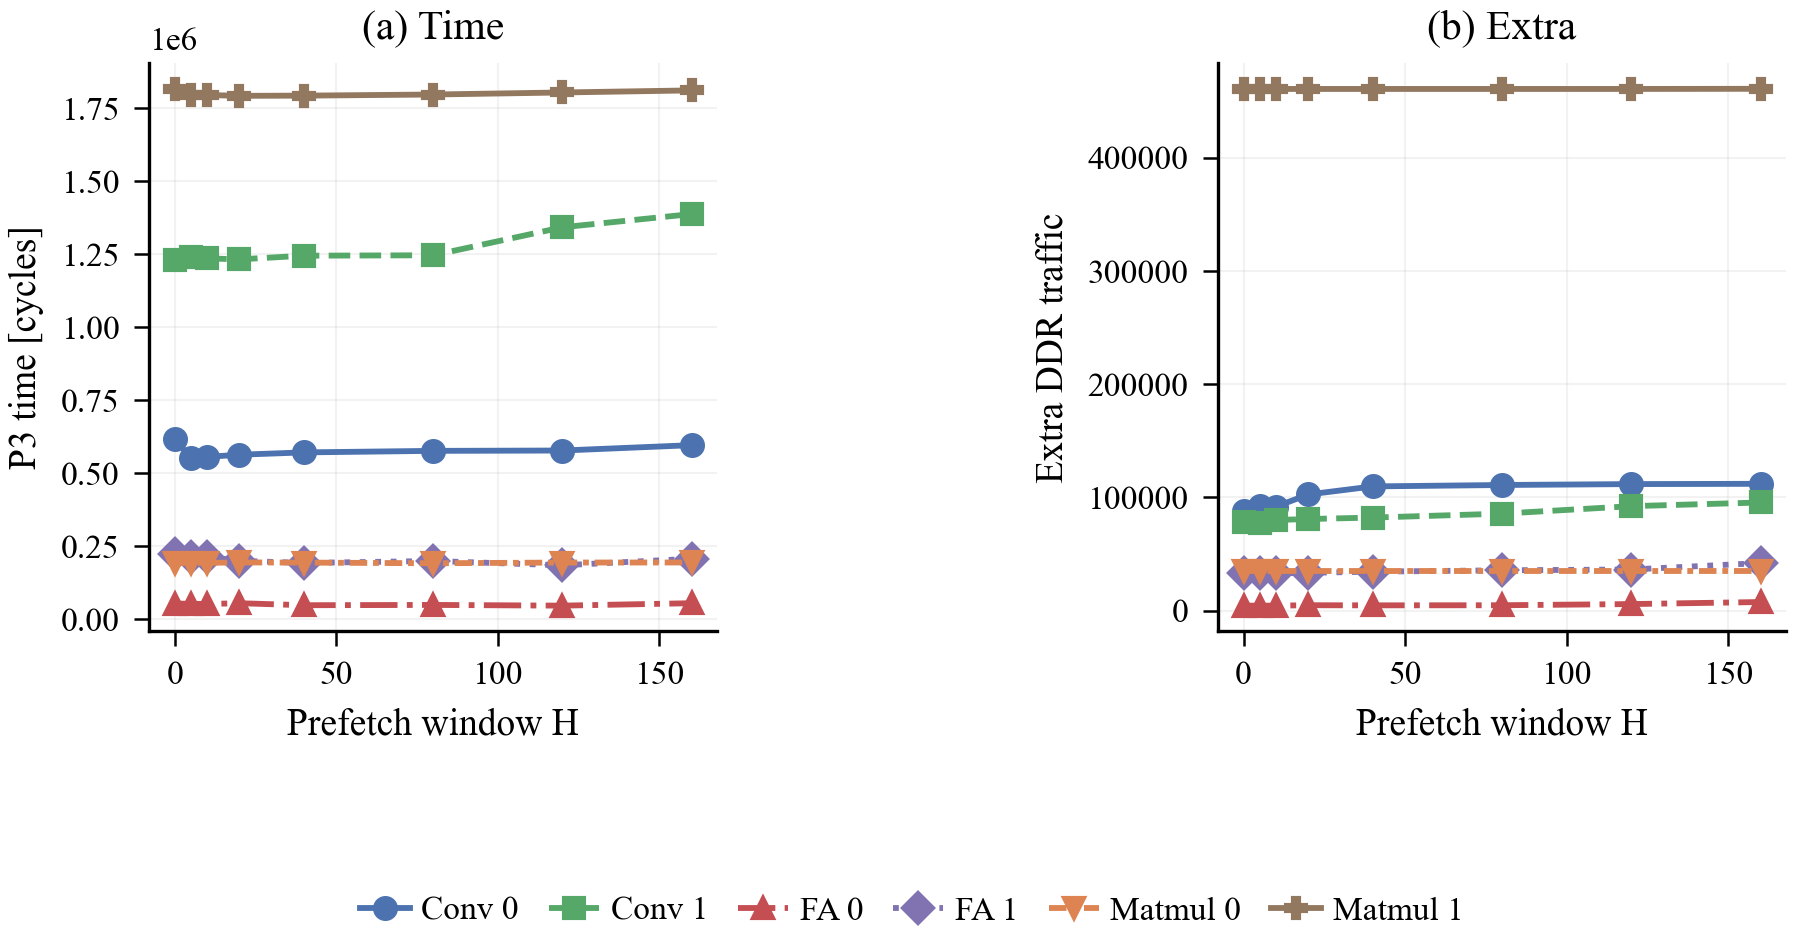

,case,order,H,extra,time,spills
0,Conv_Case0,capfit_id,0,121048,616104,157
1,Conv_Case0,p1,5,92652,553280,342
2,Conv_Case1,capfit_id,0,78056,1229560,2237
3,Conv_Case1,p1,10,382804,2840323,5490
4,FlashAttention_Case0,capfit_id,120,5832,46167,58
5,FlashAttention_Case0,p1,20,49324,148040,220
6,FlashAttention_Case1,capfit_id,120,36360,184475,256
7,FlashAttention_Case1,p1,20,245360,705328,1147
8,Matmul_Case0,capfit_id,80,34688,191353,271
9,Matmul_Case0,p1,10,311296,773921,880


> **Takeaway.** We do not claim strict monotonicity of extra over the prefetch window H. The supported conclusion is that time and extra can be optimized through separate placement choices.

In [12]:
show_png("e8_decoupling.png")

best_prefetch = (
    e8.loc[e8.groupby(["case", "order"])["time"].idxmin()]
    .sort_values(["case", "order"])
    .reset_index(drop=True)
)
display(best_prefetch)

note(
    "We do not claim strict monotonicity of extra over the prefetch window H. The "
    "supported conclusion is that time and extra can be optimized through "
    "separate placement choices."
)

## 11. D — working-set bound

The working-set bound must be read over the near-optimal-extra subset. The
minimum over *all* orders can falsely suggest a case is easy.

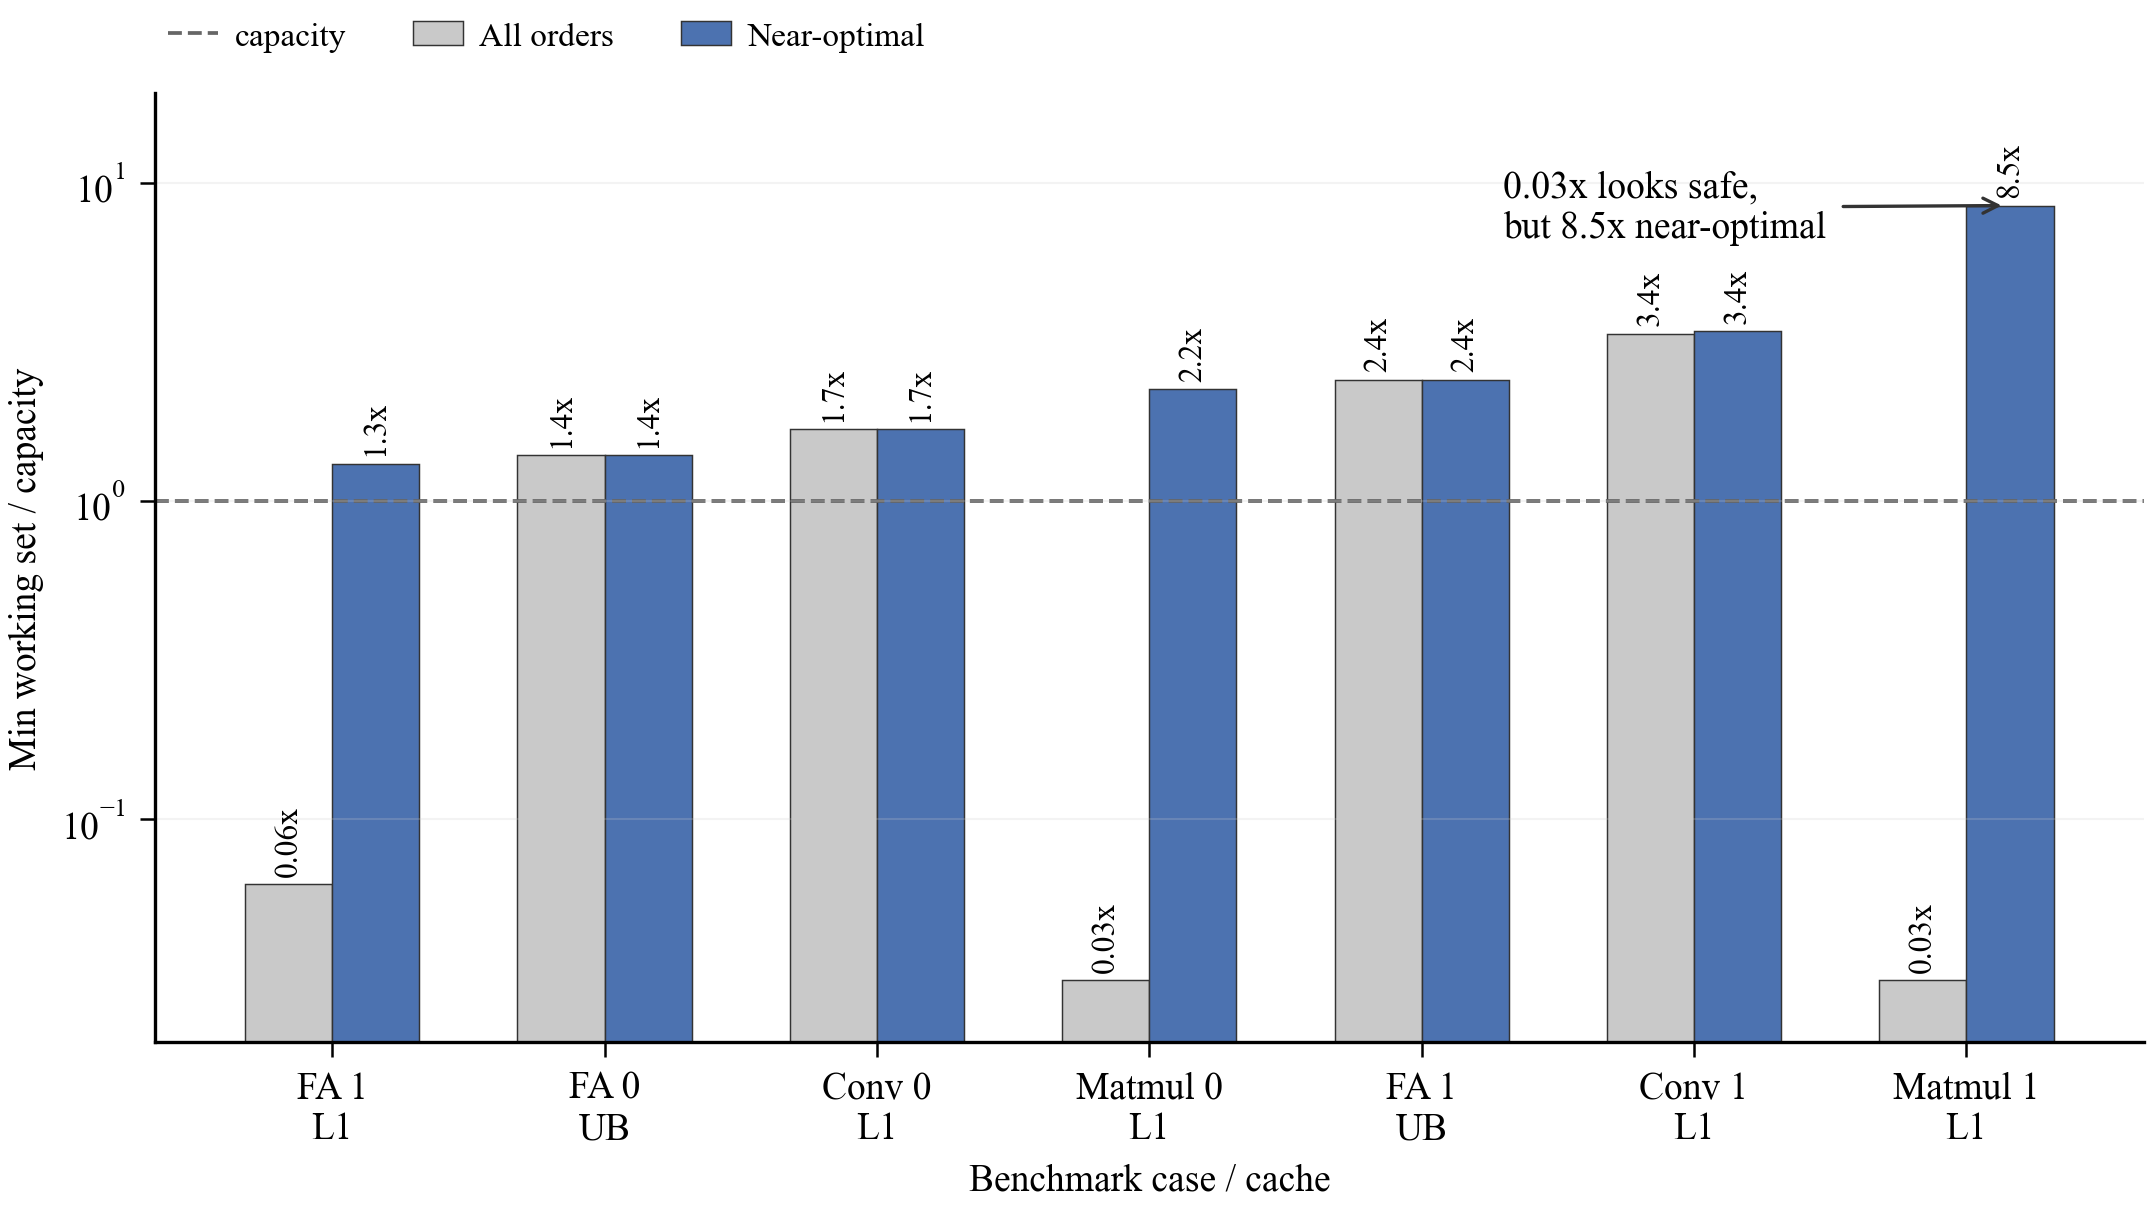

,case,cache,capacity,ratio_all,ratio_nearopt,nearopt_order,clean_frac_at_peak
0,Conv_Case0,L1,4096,1.687500,1.687500,p1,0.000000
5,Conv_Case1,L1,4096,3.365723,3.427734,capfit_id,0.841595
11,FlashAttention_Case0,UB,1024,1.394531,1.394531,id_raw,0.000000
15,FlashAttention_Case1,L1,4096,0.062500,1.312500,capfit_id,0.952381
16,FlashAttention_Case1,UB,1024,2.410156,2.410156,capfit_id,0.000000
20,Matmul_Case0,L1,4096,0.031250,2.250000,capfit_id,1.000000
25,Matmul_Case1,L1,4096,0.031250,8.500000,capfit_id,1.000000


> **Takeaway.** For Matmul_Case1/L1, ratio_all = 0.03125 but ratio_nearopt = 8.5. The unconstrained minimum is misleading; the near-optimal subset is the honest bound.

In [13]:
show_png("e9_working_set.png")

capacity_bound = e9[e9["bound_class"].eq("capacity_bound")][
    ["case", "cache", "capacity", "ratio_all", "ratio_nearopt", "nearopt_order", "clean_frac_at_peak"]
].sort_values(["case", "cache"])
display(capacity_bound)

matmul1_l1 = e9[(e9["case"].eq("Matmul_Case1")) & (e9["cache"].eq("L1"))].iloc[0]
note(
    f"For Matmul_Case1/L1, ratio_all = {matmul1_l1['ratio_all']:.5f} but "
    f"ratio_nearopt = {matmul1_l1['ratio_nearopt']:.1f}. The unconstrained minimum "
    "is misleading; the near-optimal subset is the honest bound."
)

## 12. M — portfolio trajectory

From iter034 to iter038, adding candidate orders and prefetch windows
monotonically increased the win count.

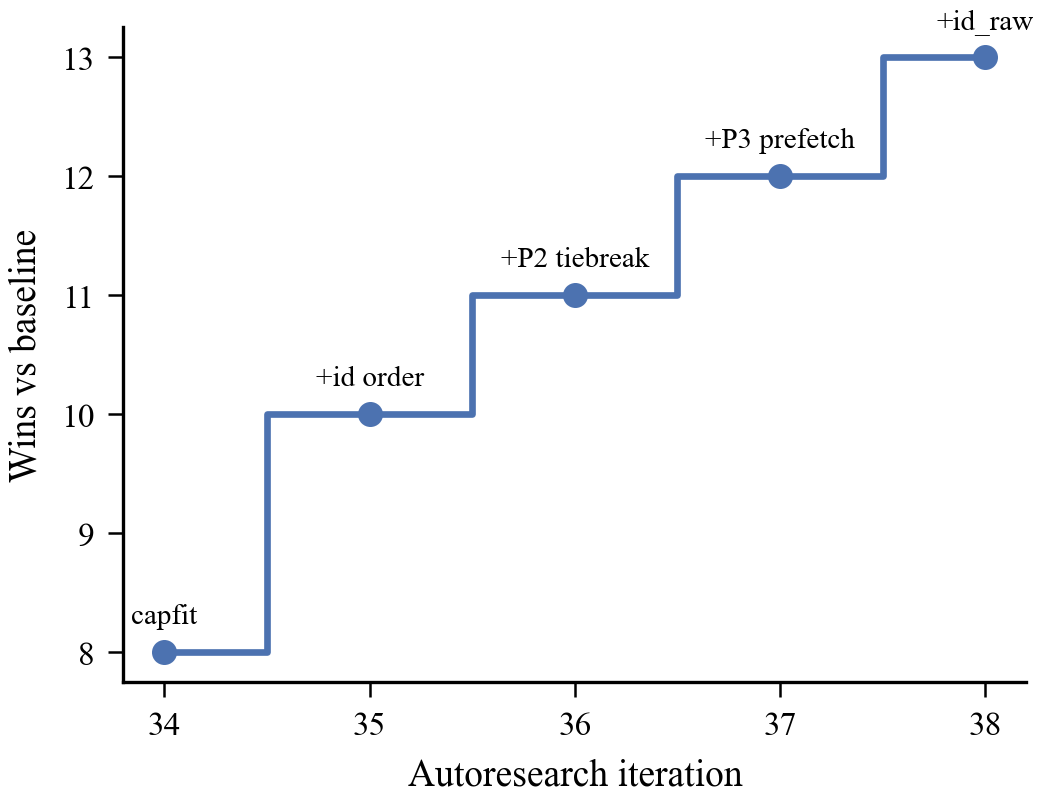

,iter,desc,wins,losses,ties
0,34,capfit_p123,8,10,0
1,35,p3_time_select,10,8,0
2,36,p2_time_bestfit,11,7,0
3,37,p3_prefetch_grid,12,6,0
4,38,id_raw_candidate,13,5,0


> **Takeaway.** The strength of the portfolio is safety, not complexity: after taking the minimum under the official key, adding a candidate cannot regress the selected result.

In [14]:
show_png("e10_portfolio.png")
display(e10)

note(
    "The strength of the portfolio is safety, not complexity: after taking the "
    "minimum under the official key, adding a candidate cannot regress the "
    "selected result."
)

### Explanatory: portfolio search trajectory

> **Explanatory figure (notebook-only) — not a paper figure.**

A richer view of the same trajectory than E10: (a) the win count broken down
by problem, and (b) aggregate P2 extra traffic and P3 time, normalized to the
first portfolio iteration.

Saved: output/03_results_report/x3_portfolio_trajectory.png


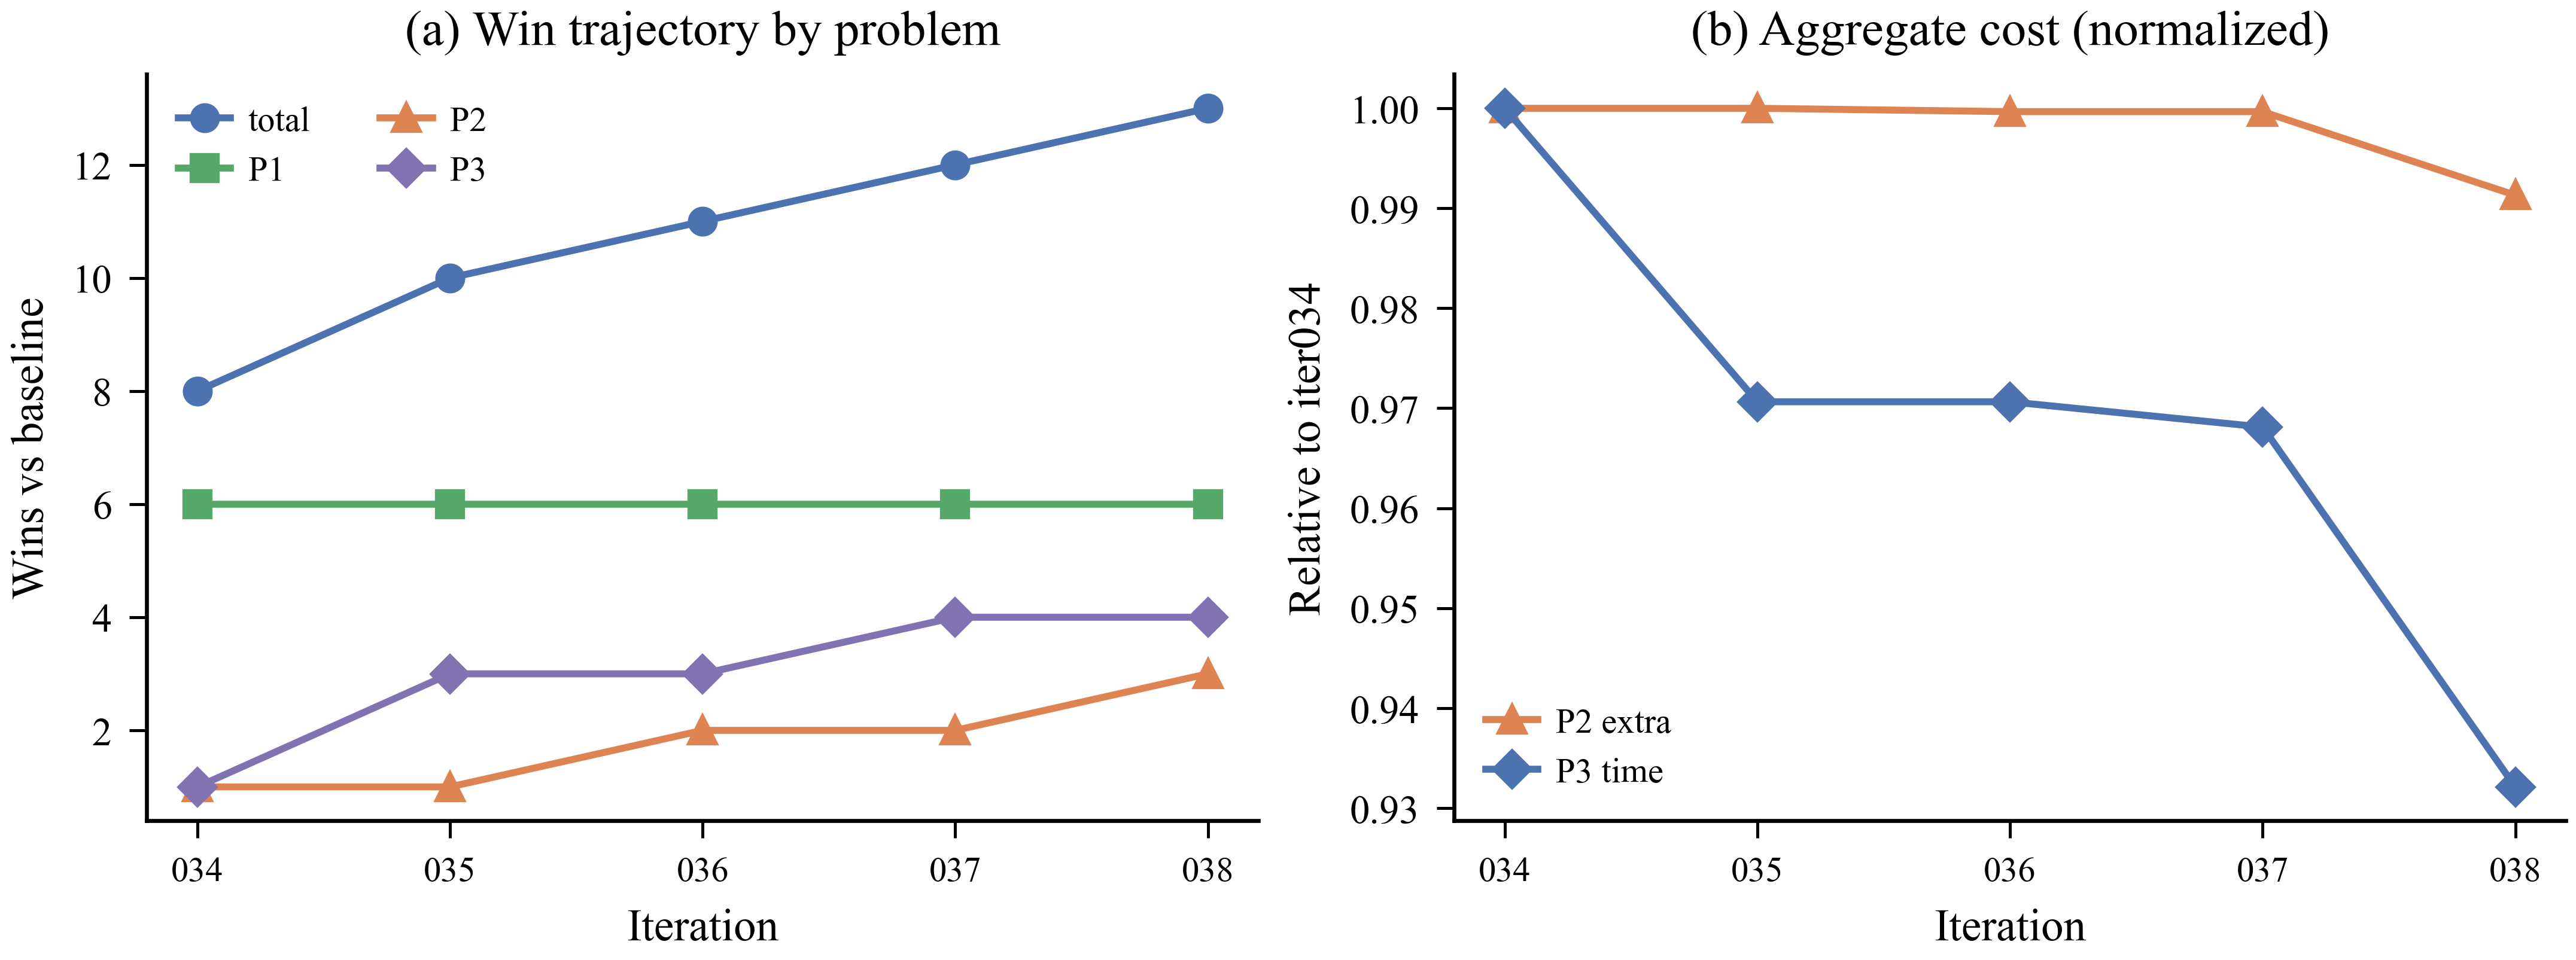

In [15]:
traj = x3_traj
xs = np.arange(len(traj))

fig, (axA, axB) = make_figure("double_col", ncols=2, height=2.7)
axA.plot(xs, traj["wins"], marker="o", color=METHOD_PALETTE["primary"], label="total")
axA.plot(xs, traj["p1_wins"], marker="s", color=METHOD_PALETTE["secondary"], label="P1")
axA.plot(xs, traj["p2_wins"], marker="^", color=METHOD_PALETTE["accent_3"], label="P2")
axA.plot(xs, traj["p3_wins"], marker="D", color=METHOD_PALETTE["accent_2"], label="P3")
axA.set_xticks(xs)
axA.set_xticklabels(traj["iter"], fontsize=7)
axA.set_xlabel("Iteration")
axA.set_ylabel("Wins vs baseline")
axA.set_title("(a) Win trajectory by problem")
axA.legend(fontsize=7, ncol=2)

p2_0 = traj["total_p2_extra"].iloc[0]
p3_0 = traj["total_p3_time"].iloc[0]
axB.plot(xs, traj["total_p2_extra"] / p2_0, marker="^", color=METHOD_PALETTE["accent_3"], label="P2 extra")
axB.plot(xs, traj["total_p3_time"] / p3_0, marker="D", color=METHOD_PALETTE["primary"], label="P3 time")
axB.set_xticks(xs)
axB.set_xticklabels(traj["iter"], fontsize=7)
axB.set_xlabel("Iteration")
axB.set_ylabel("Relative to iter034")
axB.set_title("(b) Aggregate cost (normalized)")
axB.legend(fontsize=7)
save_fig(fig, "x3_portfolio_trajectory.png")
fig

**Read.** Total wins climb 8→13 across the five portfolio iterations, and the
breakdown shows where: P1 is already saturated at 6/6, so every gain comes
from P2 (1→3) and P3 (1→4). Panel (b) confirms the mechanism — aggregate P2
extra traffic and P3 time both fall monotonically as candidates are added,
because selection keeps only improvements.

## 13. Reproducibility manifest

Numbers in this report come from `results/paper/*.csv`; paper figures come
from `output/02_paper_figures/*.png`; paper-ready copies are synced into
`paper/assets/` by `scripts/paper/sync_paper_artifacts.py`.

In [16]:
artifacts = pd.DataFrame(
    [
        {"artifact": "final solver", "path": "algorithms/autoresearch/solve.py"},
        {"artifact": "best iteration marker", "path": "algorithms/autoresearch/best_iter.txt"},
        {"artifact": "paper CSV manifest", "path": "results/paper/MANIFEST.md"},
        {"artifact": "paper number manifest", "path": "results/paper/PAPER_NUMBERS.yml"},
        {"artifact": "paper figures", "path": "output/02_paper_figures/"},
        {"artifact": "paper sync script", "path": "scripts/paper/sync_paper_artifacts.py"},
        {"artifact": "this notebook source", "path": "notebooks/03_results_report/fragments/"},
    ]
)
display(artifacts)

commands = pd.DataFrame(
    [
        {"task": "regenerate paper data", "command": "uv run python scripts/paper/inv_inventory.py && uv run python scripts/paper/prob_metrics.py"},
        {"task": "build data & problem", "command": "uv run python scripts/build_notebook.py notebooks/01_data_and_problem --execute"},
        {"task": "build paper figures", "command": "uv run python scripts/build_notebook.py notebooks/02_paper_figures --execute"},
        {"task": "build this report", "command": "uv run python scripts/build_notebook.py notebooks/03_results_report --execute"},
        {"task": "sync paper artifacts", "command": "uv run python scripts/paper/sync_paper_artifacts.py"},
        {"task": "run tests", "command": "uv run pytest -v"},
    ]
)
display(commands)

note(
    "The notebook suite is three reports: `01_data_and_problem` (data + problem "
    "framing), `02_paper_figures` (the paper-figure factory), and this "
    "`03_results_report` (evidence narrative). All read `results/paper/*.csv`."
)

,artifact,path
0,final solver,algorithms/autoresearch/solve.py
1,best iteration marker,algorithms/autoresearch/best_iter.txt
2,paper CSV manifest,results/paper/MANIFEST.md
3,paper number manifest,results/paper/PAPER_NUMBERS.yml
4,paper figures,output/02_paper_figures/
5,paper sync script,scripts/paper/sync_paper_artifacts.py
6,this notebook source,notebooks/03_results_report/fragments/


,task,command
0,regenerate paper data,uv run python scripts/paper/inv_inventory.py &...
1,build data & problem,uv run python scripts/build_notebook.py notebo...
2,build paper figures,uv run python scripts/build_notebook.py notebo...
3,build this report,uv run python scripts/build_notebook.py notebo...
4,sync paper artifacts,uv run python scripts/paper/sync_paper_artifac...
5,run tests,uv run pytest -v


> **Takeaway.** The notebook suite is three reports: `01_data_and_problem` (data + problem framing), `02_paper_figures` (the paper-figure factory), and this `03_results_report` (evidence narrative). All read `results/paper/*.csv`.